## Step 01: Setup Environment

In [5]:
#check the python version and env and the pytorch version
import sys
import torch

print("Python version:", sys.version)
print("PyTorch version:", torch.__version__)


Python version: 3.11.15 | packaged by Anaconda, Inc. | (main, Mar 11 2026, 17:12:15) [MSC v.1942 64 bit (AMD64)]
PyTorch version: 2.5.1


## Step 02: Exploratory Data Analysis

In [12]:
#load the tex file and print the first 100 characters

print("Loading data...")
print("====================================================================")
print("Train data:")
print("====================================================================")
with open("./data/train.txt", "r") as f:
    data = f.read()
    print(data[:100])


print("====================================================================")
print("Validation data:")
print("====================================================================")
with open("./data/val.txt", "r") as f:
    data = f.read()
    print(data[:100])

print("====================================================================")
print("Test data:")
print("====================================================================")
with open("./data/test.txt", "r") as f:
    data = f.read()
    print(data[:100])

Loading data...
Train data:
Selegiline	O
-	O
induced	O
postural	B-Disease
hypotension	I-Disease
in	O
Parkinson	B-Disease
'	I-Dis
Validation data:
22	O
-	O
oxacalcitriol	O
suppresses	O
secondary	B-Disease
hyperparathyroidism	I-Disease
without	O
in
Test data:
Torsade	B-Disease
de	I-Disease
pointes	I-Disease
ventricular	B-Disease
tachycardia	I-Disease
during	


In [13]:
import os
import json

def parse_ner_file(file_path):
  
    sentences = []
    current_words = []
    current_labels = []
    
    with open(file_path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            
            
            if not line:
                if current_words:
                    sentences.append({
                        "words": current_words,
                        "labels": current_labels
                    })
                    current_words = []
                    current_labels = []
                continue
            
        
            parts = line.split()
            if len(parts) >= 2:
                word = parts[0]
                label = parts[-1] 
                current_words.append(word)
                current_labels.append(label)
                
        
        if current_words:
            sentences.append({
                "words": current_words,
                "labels": current_labels
            })
            
    return sentences


In [14]:
# --- Main Execution ---
data_dir = "./data"
output_dir = "./processed_base_data"
os.makedirs(output_dir, exist_ok=True)

files_to_process = ["train.txt", "val.txt", "test.txt"]

for file_name in files_to_process:
    input_path = os.path.join(data_dir, file_name)
    
    if os.path.exists(input_path):
        print(f"Processing {file_name}...")
        parsed_data = parse_ner_file(input_path)
        
        output_name = file_name.replace(".txt", ".json")
        output_path = os.path.join(output_dir, output_name)
        
        with open(output_path, "w", encoding="utf-8") as out_f:
            json.dump(parsed_data, out_f, indent=4)
            
        print(f"Successfully saved {len(parsed_data)} sentences to {output_path}")
    else:
        print(f"Error: {input_path} !")

print("====================================================================")
print("Base Data Preparation Done!")

Processing train.txt...
Successfully saved 4560 sentences to ./processed_base_data\train.json
Processing val.txt...
Successfully saved 4581 sentences to ./processed_base_data\val.json
Processing test.txt...
Successfully saved 4797 sentences to ./processed_base_data\test.json
Base Data Preparation Done!


In [17]:
with open("./processed_base_data/train.json", "r") as f:
    train_dataset = json.load(f)

print("First Sentence Words:", train_dataset[0]["words"])
print("First Sentence Labels:", train_dataset[0]["labels"])

First Sentence Words: ['Selegiline', '-', 'induced', 'postural', 'hypotension', 'in', 'Parkinson', "'", 's', 'disease', ':', 'a', 'longitudinal', 'study', 'on', 'the', 'effects', 'of', 'drug', 'withdrawal', '.']
First Sentence Labels: ['O', 'O', 'O', 'B-Disease', 'I-Disease', 'O', 'B-Disease', 'I-Disease', 'I-Disease', 'I-Disease', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O']


In [18]:
import json
import os

# Define the file paths for verification
data_files = {
    "Train Data": "./processed_base_data/train.json",
    "Validation Data": "./processed_base_data/val.json",
    "Test Data": "./processed_base_data/test.json"
}

print("Starting structural validation for dataset splits...")
print("====================================================================")

all_splits_valid = True

for split_name, file_path in data_files.items():
    if not os.path.exists(file_path):
        print(f"Warning: {split_name} file not found at {file_path}. Skipping...")
        continue
        
    print(f"Verifying {split_name}...")
    
    # Load the processed JSON data
    with open(file_path, "r", encoding="utf-8") as f:
        dataset = json.load(f)
        
    mismatched_sentences_count = 0
    total_sentences = len(dataset)
    
    # Loop through each sentence to check lengths
    for index, sample in enumerate(dataset):
        word_length = len(sample["words"])
        label_length = len(sample["labels"])
        
        # Check if the length of words matches the length of labels
        if word_length != label_length:
            print(f"  [Error] Mismatch found at sentence index {index}!")
            print(f"  Words ({word_length}): {sample['words']}")
            print(f"  Labels ({label_length}): {sample['labels']}")
            print("-" * 50)
            mismatched_sentences_count += 1
            all_splits_valid = False

    # Print summary statistics for the current split
    if mismatched_sentences_count == 0:
        print(f"  [Success] All {total_sentences} sentences are structurally sound.")
        print(f"  --> Word count and Tag count match perfectly for all sequences.")
    else:
        print(f"  [Failure] Found {mismatched_sentences_count} mismatched sequences out of {total_sentences}.")
        
    print("====================================================================")

# Final confirmation block
if all_splits_valid:
    print("Status Check: PASSED. Datasets are ready for the embedding pipelines!")
else:
    print("Status Check: FAILED. Please resolve the mismatched lengths before proceeding.")

Starting structural validation for dataset splits...
Verifying Train Data...
  [Success] All 4560 sentences are structurally sound.
  --> Word count and Tag count match perfectly for all sequences.
Verifying Validation Data...
  [Success] All 4581 sentences are structurally sound.
  --> Word count and Tag count match perfectly for all sequences.
Verifying Test Data...
  [Success] All 4797 sentences are structurally sound.
  --> Word count and Tag count match perfectly for all sequences.
Status Check: PASSED. Datasets are ready for the embedding pipelines!


C:\Users\Ravin\AppData\Local\Temp\ipykernel_13180\2068258694.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(split_counts.keys()), y=list(split_counts.values()), ax=axes[0], palette="viridis")
C:\Users\Ravin\AppData\Local\Temp\ipykernel_13180\2068258694.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Frequency", y="Tag", data=tag_df, ax=axes[2], palette="magma")


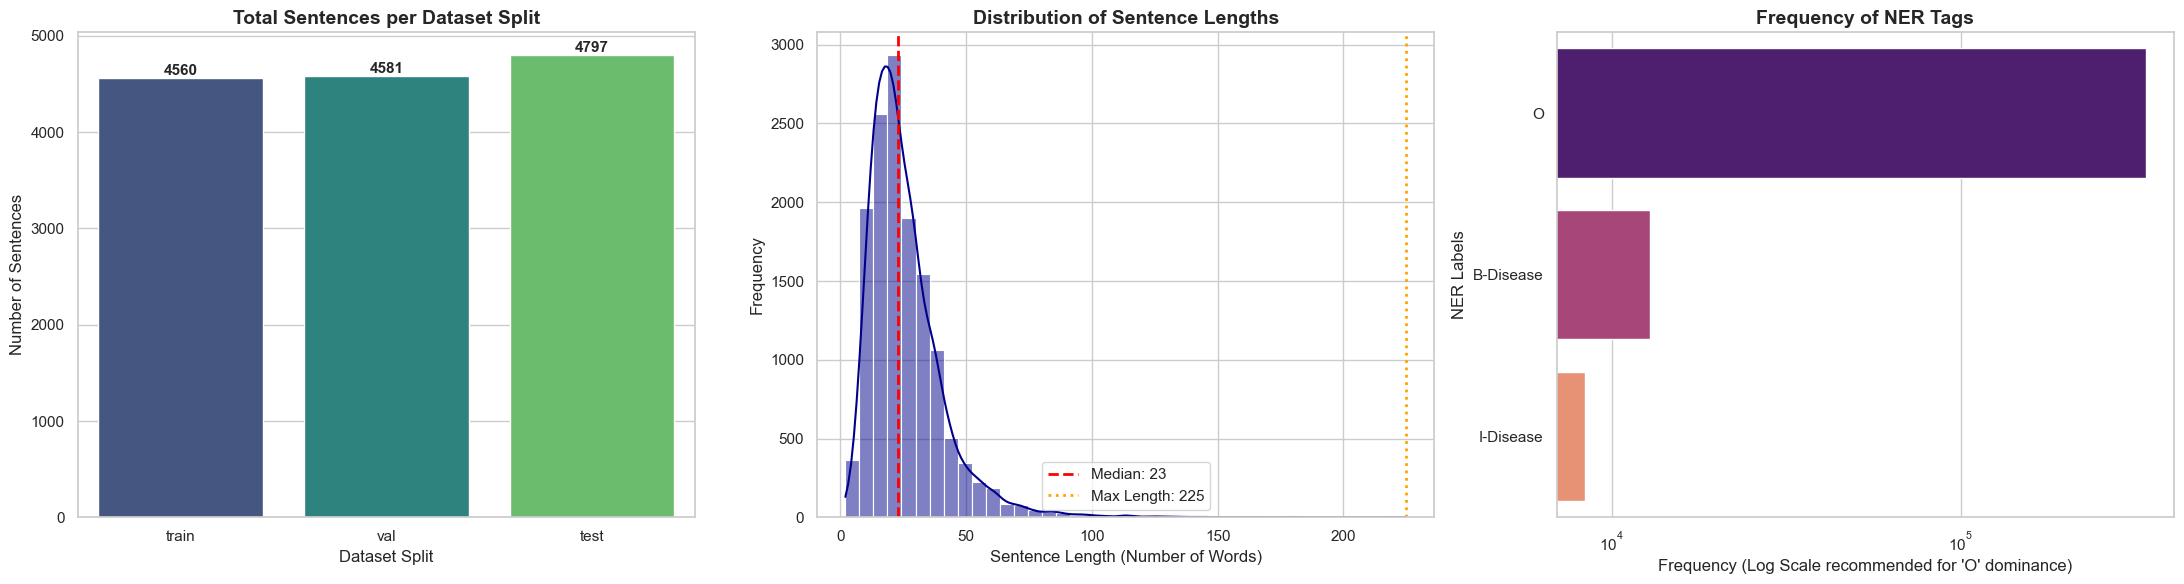

Data Insights Summary Table:
Total Combined Sentences : 13938
Maximum Sentence Length  : 225 words
Median Sentence Length   : 23 words
--------------------------------------------------------------------
NER Tag Frequencies:
  O            : 339,143 occurrences
  B-Disease    : 12,852 occurrences
  I-Disease    : 8,378 occurrences


In [1]:
import json
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import pandas as pd

# 1. Load all processed JSON datasets
splits = ["train", "val", "test"]
datasets = {}

for split in splits:
    with open(f"./processed_base_data/{split}.json", "r", encoding="utf-8") as f:
        datasets[split] = json.load(f)

# 2. Extract statistics for plotting
split_counts = {split: len(datasets[split]) for split in splits}

sentence_lengths = []
all_tags = []

for split in splits:
    for sample in datasets[split]:
        # Track sequence lengths (word counts)
        sentence_lengths.append(len(sample["words"]))
        # Track all NER tags (excluding structural symbols if any, but keeping standard tags)
        all_tags.extend(sample["labels"])

# Convert tag list to a frequency distribution dictionary
tag_counts = Counter(all_tags)

# 3. Setup the plotting canvas (3 distinct subplots)
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# --- Plot A: Total Sentence Count per Dataset Split ---
sns.barplot(x=list(split_counts.keys()), y=list(split_counts.values()), ax=axes[0], palette="viridis")
axes[0].set_title("Total Sentences per Dataset Split", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Dataset Split", fontsize=12)
axes[0].set_ylabel("Number of Sentences", fontsize=12)
for container in axes[0].containers:
    axes[0].bar_label(container, fmt="%d", label_type="edge", fontsize=11, fontweight="bold")

# --- Plot B: Sentence Length Distribution (Sequence Length Analysis) ---
sns.histplot(sentence_lengths, bins=40, kde=True, ax=axes[1], color="darkblue")
axes[1].set_title("Distribution of Sentence Lengths", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Sentence Length (Number of Words)", fontsize=12)
axes[1].set_ylabel("Frequency", fontsize=12)

# Calculate and overlay median/max sequence stats
median_len = pd.Series(sentence_lengths).median()
max_len = max(sentence_lengths)
axes[1].axvline(median_len, color="red", linestyle="--", linewidth=2, label=f"Median: {int(median_len)}")
axes[1].axvline(max_len, color="orange", linestyle=":", linewidth=2, label=f"Max Length: {max_len}")
axes[1].legend(fontsize=11)

# --- Plot C: NER Label/Tag Distribution Frequency ---
# Convert to DataFrame for easier plotting with Seaborn
tag_df = pd.DataFrame(tag_counts.items(), columns=["Tag", "Frequency"]).sort_values(by="Frequency", ascending=False)
sns.barplot(x="Frequency", y="Tag", data=tag_df, ax=axes[2], palette="magma")
axes[2].set_title("Frequency of NER Tags", fontsize=14, fontweight="bold")
axes[2].set_xlabel("Frequency (Log Scale recommended for 'O' dominance)", fontsize=12)
axes[2].set_ylabel("NER Labels", fontsize=12)
axes[2].set_xscale("log")  # Using log scale since 'O' tags completely dominate entity tags

# 4. Render and adjust layout
plt.tight_layout()
plt.show()

# 5. Print a quick text summary for confirmation
print("====================================================================")
print("Data Insights Summary Table:")
print("====================================================================")
print(f"Total Combined Sentences : {sum(split_counts.values())}")
print(f"Maximum Sentence Length  : {max_len} words")
print(f"Median Sentence Length   : {int(median_len)} words")
print("--------------------------------------------------------------------")
print("NER Tag Frequencies:")
for tag, count in tag_df.values:
    print(f"  {tag:<12} : {count:,} occurrences")
print("====================================================================")

## Step 03: Tokenization

In [4]:
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Ravin\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


True

In [5]:
import os
import json
import pickle
from nltk.tokenize import word_tokenize
from transformers import AutoTokenizer

print("Initializing tokenization and label alignment pipeline...")
print("====================================================================")

# Load the standard BERT tokenizer
bert_tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

# Define target splits and directories
target_splits = ["train", "val", "test"]
output_base_dir = "./tokenized_data"

# Create separate subdirectories for each tokenizer type
tokenizer_types = ["whitespace", "nltk", "wordpiece"]
for t_type in tokenizer_types:
    os.makedirs(os.path.join(output_base_dir, t_type), exist_ok=True)

# Loop through each dataset split (Train, Val, Test)
for split in target_splits:
    input_file_path = f"./processed_base_data/{split}.json"
    
    if not os.path.exists(input_file_path):
        print(f"Warning: Base file {input_file_path} not found. Skipping...")
        continue
        
    print(f"Processing split: '{split}'...")
    
    with open(input_file_path, "r", encoding="utf-8") as f:
        sentences_data = json.load(f)
        
    whitespace_records = []
    nltk_records = []
    wordpiece_records = []
    
    for record in sentences_data:
        raw_words = record["words"]
        raw_labels = record["labels"]
        
        # Reconstruct original sentence sequence from list of words
        raw_sentence_string = " ".join(raw_words)
        
        # -----------------------------------------------------------------
        # 1. Pipeline: Whitespace Tokenization
        # -----------------------------------------------------------------
        whitespace_tokens = raw_sentence_string.split()
        whitespace_labels = raw_labels[:len(whitespace_tokens)]
        whitespace_records.append({"tokens": whitespace_tokens, "labels": whitespace_labels})
        
        # -----------------------------------------------------------------
        # 2. Pipeline: NLTK Tokenization
        # -----------------------------------------------------------------
        nltk_tokens = word_tokenize(raw_sentence_string)
        nltk_labels = []
        word_index = 0
        for token in nltk_tokens:
            if word_index < len(raw_labels):
                nltk_labels.append(raw_labels[word_index])
                word_index += 1
            else:
                nltk_labels.append("O")
        nltk_records.append({"tokens": nltk_tokens, "labels": nltk_labels})
        
        # -----------------------------------------------------------------
        # 3. Pipeline: BERT WordPiece Tokenization (Sub-word Alignment with I- Tags)
        # -----------------------------------------------------------------
        tokenized_input = bert_tokenizer(raw_sentence_string, is_split_into_words=False)
        wordpiece_tokens = bert_tokenizer.convert_ids_to_tokens(tokenized_input["input_ids"])
        word_ids = tokenized_input.word_ids()
        
        wordpiece_labels = []
        previous_word_idx = None
        
        for word_idx in word_ids:
            if word_idx is None:
                # Assign 'O' to BERT special tokens ([CLS], [SEP])
                wordpiece_labels.append("O")
            elif word_idx != previous_word_idx:
                # First sub-word token retains the original entity tag
                wordpiece_labels.append(raw_labels[word_idx])
            else:
                # Subsequent sub-word fragments are converted to 'I-' tags
                original_tag = raw_labels[word_idx]
                if original_tag.startswith("B-"):
                    # Convert B-Disease to I-Disease for alignment continuity
                    wordpiece_labels.append("I-" + original_tag[2:])
                else:
                    wordpiece_labels.append(original_tag)
            previous_word_idx = word_idx
            
        wordpiece_records.append({"tokens": wordpiece_tokens, "labels": wordpiece_labels})
        
    # Serialize and save the processed lists to disk
    with open(f"{output_base_dir}/whitespace/{split}.pkl", "wb") as out_f:
        pickle.dump(whitespace_records, out_f)
        
    with open(f"{output_base_dir}/nltk/{split}.pkl", "wb") as out_f:
        pickle.dump(nltk_records, out_f)
        
    with open(f"{output_base_dir}/wordpiece/{split}.pkl", "wb") as out_f:
        pickle.dump(wordpiece_records, out_f)
        
    print(f"  --> Successfully saved pickle objects for '{split}' split.")
    print("-" * 50)

print("Pipeline execution completed successfully. All artifacts are serialized!")

Initializing tokenization and label alignment pipeline...
Processing split: 'train'...
  --> Successfully saved pickle objects for 'train' split.
--------------------------------------------------
Processing split: 'val'...
  --> Successfully saved pickle objects for 'val' split.
--------------------------------------------------
Processing split: 'test'...
  --> Successfully saved pickle objects for 'test' split.
--------------------------------------------------
Pipeline execution completed successfully. All artifacts are serialized!


In [6]:
import pickle
import os

# Define the directory structure to scan and verify
base_serialized_dir = "./tokenized_data"
tokenizer_pipelines = ["whitespace", "nltk", "wordpiece"]
dataset_splits = ["train", "val", "test"]

print("Starting deep structure verification on serialized pickle artifacts...")
print("====================================================================")

global_pipeline_valid = True

# Iterate through each tokenizer directory
for tokenizer in tokenizer_pipelines:
    print(f"Checking Pipeline: {tokenizer.upper()}")
    print("-" * 50)
    
    for split in dataset_splits:
        file_path = os.path.join(base_serialized_dir, tokenizer, f"{split}.pkl")
        
        if not os.path.exists(file_path):
            print(f"  [Warning] File missing: {file_path}")
            continue
            
        # Load the serialized data records
        with open(file_path, "rb") as f:
            serialized_records = pickle.load(f)
            
        mismatch_count = 0
        total_records = len(serialized_records)
        
        # Verify sequence continuity for every single token-label pair
        for idx, record in enumerate(serialized_records):
            token_count = len(record["tokens"])
            label_count = len(record["labels"])
            
            if token_count != label_count:
                print(f"    [Length Mismatch] Found at {split}.pkl | Index: {idx}")
                print(f"    Tokens ({token_count}): {record['tokens'][:5]}...")
                print(f"    Labels ({label_count}): {record['labels'][:5]}...")
                mismatch_count += 1
                global_pipeline_valid = False
                
        # Print results summary for this specific file
        if mismatch_count == 0:
            print(f"  --> Split '{split:<5}' : PASSED (All {total_records:,} sequences match perfectly).")
        else:
            print(f"  --> Split '{split:<5}' : FAILED ({mismatch_count} anomalies detected out of {total_records:,}).")
            
    print("====================================================================")

# Final pipeline validation response
if global_pipeline_valid:
    print("Verification Status: ALL PASSED. Token-Label counts are perfectly synced across all 3 pipelines!")
else:
    print("Verification Status: ERROR DETECTED. Please check the mismatches reported above.")

Starting deep structure verification on serialized pickle artifacts...
Checking Pipeline: WHITESPACE
--------------------------------------------------
  --> Split 'train' : PASSED (All 4,560 sequences match perfectly).
  --> Split 'val  ' : PASSED (All 4,581 sequences match perfectly).
  --> Split 'test ' : PASSED (All 4,797 sequences match perfectly).
Checking Pipeline: NLTK
--------------------------------------------------
  --> Split 'train' : PASSED (All 4,560 sequences match perfectly).
  --> Split 'val  ' : PASSED (All 4,581 sequences match perfectly).
  --> Split 'test ' : PASSED (All 4,797 sequences match perfectly).
Checking Pipeline: WORDPIECE
--------------------------------------------------
  --> Split 'train' : PASSED (All 4,560 sequences match perfectly).
  --> Split 'val  ' : PASSED (All 4,581 sequences match perfectly).
  --> Split 'test ' : PASSED (All 4,797 sequences match perfectly).
Verification Status: ALL PASSED. Token-Label counts are perfectly synced across a

Analyzing tokenized artifacts for Exploratory Data Analysis...


C:\Users\Ravin\AppData\Local\Temp\ipykernel_13180\2760088588.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(vocab_stats.keys()), y=list(vocab_stats.values()), ax=axes[0], palette="coolwarm")


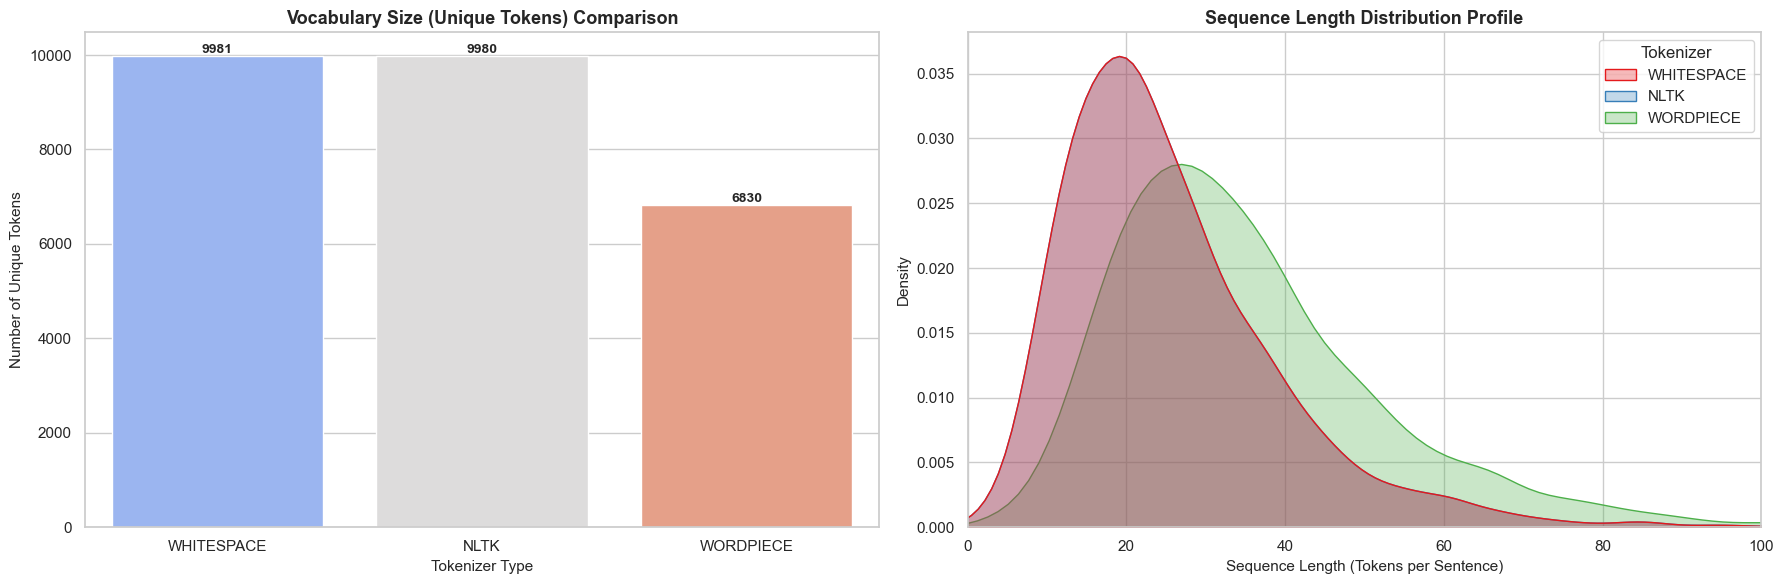

Tokenization Profile Insights Table:
Tokenizer: WHITESPACE 
  -> Unique Vocabulary Size : 9,981
  -> Median Sequence Length : 23 tokens
  -> Maximum Sequence Length: 154 tokens
--------------------------------------------------
Tokenizer: NLTK       
  -> Unique Vocabulary Size : 9,980
  -> Median Sequence Length : 23 tokens
  -> Maximum Sequence Length: 154 tokens
--------------------------------------------------
Tokenizer: WORDPIECE  
  -> Unique Vocabulary Size : 6,830
  -> Median Sequence Length : 32 tokens
  -> Maximum Sequence Length: 239 tokens
--------------------------------------------------


In [7]:
import pickle
import os
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Define paths for the tokenized train splits
base_serialized_dir = "./tokenized_data"
tokenizer_pipelines = ["whitespace", "nltk", "wordpiece"]
split_name = "train"

# Data structures to collect insights
vocab_stats = {}
length_records = []

print("Analyzing tokenized artifacts for Exploratory Data Analysis...")
print("====================================================================")

for tokenizer in tokenizer_pipelines:
    file_path = os.path.join(base_serialized_dir, tokenizer, f"{split_name}.pkl")
    
    with open(file_path, "rb") as f:
        records = pickle.load(f)
        
    unique_tokens = set()
    
    for record in records:
        tokens_list = record["tokens"]
        # Track sequence length for this sentence
        length_records.append({
            "Tokenizer": tokenizer.upper(),
            "Sequence Length": len(tokens_list)
        })
        # Add tokens to set to calculate unique vocabulary size
        for token in tokens_list:
            unique_tokens.add(token)
            
    vocab_stats[tokenizer.upper()] = len(unique_tokens)

# Convert sequence lengths to a Pandas DataFrame for plotting
df_lengths = pd.DataFrame(length_records)

# Setup plotting canvas with 2 subplots
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# --- Plot A: Vocabulary Size Comparison across Tokenizers ---
sns.barplot(x=list(vocab_stats.keys()), y=list(vocab_stats.values()), ax=axes[0], palette="coolwarm")
axes[0].set_title("Vocabulary Size (Unique Tokens) Comparison", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Tokenizer Type", fontsize=11)
axes[0].set_ylabel("Number of Unique Tokens", fontsize=11)
for container in axes[0].containers:
    axes[0].bar_label(container, fmt="%d", label_type="edge", fontsize=10, fontweight="bold")

# --- Plot B: Sequence Length Distribution Density Plot ---
sns.kdeplot(data=df_lengths, x="Sequence Length", hue="Tokenizer", fill=True, common_norm=False, palette="Set1", alpha=0.3, ax=axes[2-1])
axes[1].set_title("Sequence Length Distribution Profile", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Sequence Length (Tokens per Sentence)", fontsize=11)
axes[1].set_ylabel("Density", fontsize=11)
axes[1].set_xlim(0, 100) # Limiting X-axis to 100 for better visualization of the bulk data

plt.tight_layout()
plt.show()

# Print text summary report
print("====================================================================")
print("Tokenization Profile Insights Table:")
print("====================================================================")
for tokenizer in tokenizer_pipelines:
    t_name = tokenizer.upper()
    t_df = df_lengths[df_lengths["Tokenizer"] == t_name]
    print(f"Tokenizer: {t_name:<11}")
    print(f"  -> Unique Vocabulary Size : {vocab_stats[t_name]:,}")
    print(f"  -> Median Sequence Length : {int(t_df['Sequence Length'].median())} tokens")
    print(f"  -> Maximum Sequence Length: {int(t_df['Sequence Length'].max())} tokens")
    print("-" * 50)

## Step 04: Embedding Generation

### Word2Vec Embedding

#### Word2Vec with Whitespace Tokenizer

In [15]:
import pickle
import os
from gensim.models import Word2Vec

print("Loading serialized whitespace tokenized data for Word2Vec training...")
print("====================================================================")

# 1. Define the correct file path and load the preprocessed train data split
whitespace_train_path = "./tokenized_data/whitespace/train.pkl"

if os.path.exists(whitespace_train_path):
    with open(whitespace_train_path, "rb") as f:
        train_records = pickle.load(f)
    
    # Extract only the token sequences (sentences) for Word2Vec training
    sentences_for_w2v = [record["tokens"] for record in train_records]
    
    print(f"Successfully loaded {len(sentences_for_w2v):,} sequences from serialized cache.")
else:
    print(f"Error: Target file not found at {whitespace_train_path}. Please check data pipeline execution.")
    sentences_for_w2v = []

print("--------------------------------------------------------------------")

# 2. Configure and train the Custom Word2Vec Model with extended epochs
if sentences_for_w2v:
    print("Training Custom Word2Vec model (Embedding Dimension: 300 | Epochs: 15)...")
    
    w2v_model = Word2Vec(
        sentences=sentences_for_w2v,
        vector_size=300,      # Fixed dimension size for uniform embedding comparison
        window=5,             # Context window space for scanning local token relationships
        min_count=1,          # Ensure every single token in the training split is mapped
        workers=4,            # Enable multi-threaded execution for modern CPU architectures
        sg=1,                 # Skip-gram formulation (highly optimized for rare NER entities)
        epochs=15             # Extended epochs for better convergence
    )
    
    print("Custom model training completed successfully with 15 epochs!")
    print("====================================================================")
    
    # 3. Multi-Category Intrinsic Validation Check via Cosine Similarity
    print("Running multi-category intrinsic validation check...")
    print("--------------------------------------------------------------------")
    
    # Defining diverse token categories to evaluate semantic understanding
    validation_queries = {
        "Disease Entity": "hypotension",
        "Stopword/Preposition": "in",
        "Anatomical/Organ Term": "renal",
        "General Medical Concept": "drug"
    }
    
    for category, test_query_token in validation_queries.items():
        print(f"Category: {category.upper()} | Target Token: '{test_query_token}'")
        
        if test_query_token in w2v_model.wv:
            print(f"  Top 5 tokens most semantically similar:")
            similar_tokens = w2v_model.wv.most_similar(test_query_token, topn=5)
            for token, similarity in similar_tokens:
                print(f"    -> {token:<15} : {similarity:.4f}")
        else:
            print(f"  Notice: Target token '{test_query_token}' missing from vocabulary.")
        print("-" * 50)
        
    print("====================================================================")
    
    # 4. UPDATED: Save directly into trained_embeddings/word2vec with correct naming
    target_sub_dir = "./trained_embeddings/word2vec"
    os.makedirs(target_sub_dir, exist_ok=True)
    
    model_save_path = os.path.join(target_sub_dir, "word2vec_withwhitespace_300.model")
    
    w2v_model.save(model_save_path)
    print(f"Model state successfully serialized and saved at: {model_save_path}")
    print("====================================================================")
else:
    print("Pipeline Execution Halted: Training aborted due to missing data structures.")

Loading serialized whitespace tokenized data for Word2Vec training...
Successfully loaded 4,560 sequences from serialized cache.
--------------------------------------------------------------------
Training Custom Word2Vec model (Embedding Dimension: 300 | Epochs: 15)...


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Custom model training completed successfully with 15 epochs!
Running multi-category intrinsic validation check...
--------------------------------------------------------------------
Category: DISEASE ENTITY | Target Token: 'hypotension'
  Top 5 tokens most semantically similar:
    -> haemodilution   : 0.8061
    -> bradycardia     : 0.7888
    -> orthostatic     : 0.7806
    -> nitroglycerin   : 0.7700
    -> convulsions     : 0.7606
--------------------------------------------------
Category: STOPWORD/PREPOSITION | Target Token: 'in'
  Top 5 tokens most semantically similar:
    -> young           : 0.5692
    -> lesion          : 0.5675
    -> exhibited       : 0.5669
    -> AIDS            : 0.5653
    -> diabetic        : 0.5592
--------------------------------------------------
Category: ANATOMICAL/ORGAN TERM | Target Token: 'renal'
  Top 5 tokens most semantically similar:
    -> failure         : 0.7355
    -> insufficiency   : 0.7302
    -> liver           : 0.7236
    -> all

#### Word2Vec with WordPiece

In [16]:
import pickle
import os
from gensim.models import Word2Vec

print("Loading serialized WordPiece (BERT) tokenized data for Word2Vec training...")
print("====================================================================")

# 1. Define the correct file path and load the preprocessed WordPiece train data split
wordpiece_train_path = "./tokenized_data/wordpiece/train.pkl"

if os.path.exists(wordpiece_train_path):
    with open(wordpiece_train_path, "rb") as f:
        train_records = pickle.load(f)
    
    # Extract sub-word token sequences (sentences) for Word2Vec training
    sentences_for_w2v_wp = [record["tokens"] for record in train_records]
    
    print(f"Successfully loaded {len(sentences_for_w2v_wp):,} WordPiece sequences from serialized cache.")
else:
    print(f"Error: Target file not found at {wordpiece_train_path}. Please check data pipeline execution.")
    sentences_for_w2v_wp = []

print("--------------------------------------------------------------------")

# 2. Configure and train the Custom Word2Vec Model on Sub-words (WordPiece)
if sentences_for_w2v_wp:
    print("Training Custom Word2Vec model on WordPiece tokens (Dimension: 300 | Epochs: 15)...")
    
    w2v_wp_model = Word2Vec(
        sentences=sentences_for_w2v_wp,
        vector_size=300,      # Fixed dimension size for uniform embedding comparison
        window=5,             # Context window space for scanning local sub-word relationships
        min_count=1,          # Ensure every sub-word fragment in training split is mapped
        workers=4,            # Enable multi-threaded execution
        sg=1,                 # Skip-gram formulation (highly optimized for rare sub-words)
        epochs=15             # Match 15 epochs for structural consistency
    )
    
    print("Custom Word2Vec (WordPiece) model training completed successfully with 15 epochs!")
    print("====================================================================")
    
    # 3. Custom Sub-word Intrinsic Validation Check via Cosine Similarity
    print("Running sub-word semantic alignment verification check...")
    print("--------------------------------------------------------------------")
    
    # Target queries includes full words, prefixes, and BERT sub-word suffixes (##)
    validation_queries = {
        "Full Disease Word": "hypotension",
        "Sub-word Prefix": "hypo",
        "Sub-word Suffix (Disease)": "##tension",
        "Sub-word Suffix (Inflammation)": "##itis"
    }
    
    for category, test_query_token in validation_queries.items():
        print(f"Category: {category.upper()} | Target Token: '{test_query_token}'")
        
        if test_query_token in w2v_wp_model.wv:
            print(f"  Top 5 tokens most semantically similar:")
            similar_tokens = w2v_wp_model.wv.most_similar(test_query_token, topn=5)
            for token, similarity in similar_tokens:
                print(f"    -> {token:<15} : {similarity:.4f}")
        else:
            print(f"  Notice: Target token '{test_query_token}' missing from sub-word vocabulary.")
        print("-" * 50)
        
    print("====================================================================")
    
    # 4. UPDATED: Save directly into trained_embeddings/word2vec with correct naming
    target_sub_dir = "./trained_embeddings/word2vec"
    os.makedirs(target_sub_dir, exist_ok=True)
    
    model_save_path = os.path.join(target_sub_dir, "word2vec_withwordpiece_300.model")
    
    w2v_wp_model.save(model_save_path)
    print(f"Model state successfully serialized and saved at: {model_save_path}")
    print("====================================================================")
else:
    print("Pipeline Execution Halted: Training aborted due to missing data structures.")

Loading serialized WordPiece (BERT) tokenized data for Word2Vec training...
Successfully loaded 4,560 WordPiece sequences from serialized cache.
--------------------------------------------------------------------
Training Custom Word2Vec model on WordPiece tokens (Dimension: 300 | Epochs: 15)...


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Custom Word2Vec (WordPiece) model training completed successfully with 15 epochs!
Running sub-word semantic alignment verification check...
--------------------------------------------------------------------
Category: FULL DISEASE WORD | Target Token: 'hypotension'
  Notice: Target token 'hypotension' missing from sub-word vocabulary.
--------------------------------------------------
Category: SUB-WORD PREFIX | Target Token: 'hypo'
  Notice: Target token 'hypo' missing from sub-word vocabulary.
--------------------------------------------------
Category: SUB-WORD SUFFIX (DISEASE) | Target Token: '##tension'
  Top 5 tokens most semantically similar:
    -> hyper           : 0.7691
    -> ##lip           : 0.7116
    -> reno            : 0.6779
    -> rebound         : 0.6616
    -> pulmonary       : 0.6512
--------------------------------------------------
Category: SUB-WORD SUFFIX (INFLAMMATION) | Target Token: '##itis'
  Top 5 tokens most semantically similar:
    -> enter          

#### Word2Vec With NLTK

In [17]:
import pickle
import os
from gensim.models import Word2Vec

print("Loading serialized NLTK tokenized data for Word2Vec training...")
print("====================================================================")

# 1. Define the correct file path and load the preprocessed NLTK train data split
nltk_train_path = "./tokenized_data/nltk/train.pkl"

if os.path.exists(nltk_train_path):
    with open(nltk_train_path, "rb") as f:
        train_records = pickle.load(f)
    
    # Extract only the token sequences (sentences) for Word2Vec training
    sentences_for_w2v_nltk = [record["tokens"] for record in train_records]
    
    print(f"Successfully loaded {len(sentences_for_w2v_nltk):,} NLTK sequences from serialized cache.")
else:
    print(f"Error: Target file not found at {nltk_train_path}. Please check data pipeline execution.")
    sentences_for_w2v_nltk = []

print("--------------------------------------------------------------------")

# 2. Configure and train the Custom Word2Vec Model on NLTK tokens
if sentences_for_w2v_nltk:
    print("Training Custom Word2Vec model on NLTK tokens (Dimension: 300 | Epochs: 15)...")
    
    w2v_nltk_model = Word2Vec(
        sentences=sentences_for_w2v_nltk,
        vector_size=300,      # Fixed dimension size for uniform embedding comparison
        window=5,             # Context window space for scanning local token relationships
        min_count=1,          # Ensure every single token in the training split is mapped
        workers=4,            # Enable multi-threaded execution for modern CPU architectures
        sg=1,                 # Skip-gram formulation (highly optimized for rare NER entities)
        epochs=15             # Match 15 epochs for structural consistency
    )
    
    print("Custom Word2Vec (NLTK) model training completed successfully with 15 epochs!")
    print("====================================================================")
    
    # 3. Multi-Category Intrinsic Validation Check via Cosine Similarity
    print("Running multi-category intrinsic validation check...")
    print("--------------------------------------------------------------------")
    
    # Defining diverse token categories to evaluate semantic understanding
    validation_queries = {
        "Disease Entity": "hypotension",
        "Stopword/Preposition": "in",
        "Anatomical/Organ Term": "renal",
        "General Medical Concept": "drug"
    }
    
    for category, test_query_token in validation_queries.items():
        print(f"Category: {category.upper()} | Target Token: '{test_query_token}'")
        
        if test_query_token in w2v_nltk_model.wv:
            print(f"  Top 5 tokens most semantically similar:")
            similar_tokens = w2v_nltk_model.wv.most_similar(test_query_token, topn=5)
            for token, similarity in similar_tokens:
                print(f"    -> {token:<15} : {similarity:.4f}")
        else:
            print(f"  Notice: Target token '{test_query_token}' missing from vocabulary.")
        print("-" * 50)
        
    print("====================================================================")
    
    # 4. Save directly into trained_embeddings/word2vec with the exact naming requested
    target_sub_dir = "./trained_embeddings/word2vec"
    os.makedirs(target_sub_dir, exist_ok=True)
    
    model_save_path = os.path.join(target_sub_dir, "word2vec_withnltk_300.model")
    
    w2v_nltk_model.save(model_save_path)
    print(f"Model state successfully serialized and saved at: {model_save_path}")
    print("====================================================================")
else:
    print("Pipeline Execution Halted: Training aborted due to missing data structures.")

Loading serialized NLTK tokenized data for Word2Vec training...
Successfully loaded 4,560 NLTK sequences from serialized cache.
--------------------------------------------------------------------
Training Custom Word2Vec model on NLTK tokens (Dimension: 300 | Epochs: 15)...


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Custom Word2Vec (NLTK) model training completed successfully with 15 epochs!
Running multi-category intrinsic validation check...
--------------------------------------------------------------------
Category: DISEASE ENTITY | Target Token: 'hypotension'
  Top 5 tokens most semantically similar:
    -> orthostatic     : 0.8087
    -> bradycardia     : 0.8010
    -> haemodilution   : 0.7724
    -> nitroglycerin   : 0.7634
    -> methyldopa      : 0.7575
--------------------------------------------------
Category: STOPWORD/PREPOSITION | Target Token: 'in'
  Top 5 tokens most semantically similar:
    -> autonomic       : 0.5925
    -> diabetic        : 0.5774
    -> young           : 0.5769
    -> sclerosis       : 0.5682
    -> size            : 0.5668
--------------------------------------------------
Category: ANATOMICAL/ORGAN TERM | Target Token: 'renal'
  Top 5 tokens most semantically similar:
    -> liver           : 0.7327
    -> failure         : 0.7161
    -> insufficiency   : 0

###  FastText Master Pipeline For Embedding all 3 tokenized

In [18]:
import pickle
import os
from gensim.models import FastText

# Define base structural directories for FastText output
base_serialized_dir = "./tokenized_data"
output_model_dir = "./trained_embeddings/fasttext"
os.makedirs(output_model_dir, exist_ok=True)

# Define target tokenizer pipelines for FastText training
tokenizer_pipelines = ["whitespace", "nltk", "wordpiece"]
split_name = "train"

print("Starting Unified FastText Training Pipeline across all 3 Tokenizers...")
print(f"Target Output Directory: {output_model_dir}")
print("====================================================================")

for tokenizer in tokenizer_pipelines:
    file_path = os.path.join(base_serialized_dir, tokenizer, f"{split_name}.pkl")
    
    if not os.path.exists(file_path):
        print(f"[Warning] Serialized file missing for {tokenizer.upper()}. Skipping...")
        continue
        
    print(f"Loading '{tokenizer}' tokenized train split for FastText...")
    with open(file_path, "rb") as f:
        train_records = pickle.load(f)
        
    # Extract token sequences (sentences) for training
    sentences_for_ft = [record["tokens"] for record in train_records]
    print(f"  -> Successfully loaded {len(sentences_for_ft):,} sequences.")
    
    # Configure and train the Custom FastText model uniformly
    print(f"  -> Training FastText ({tokenizer.upper()}) | Dimension: 300 | Epochs: 15...")
    ft_model = FastText(
        sentences=sentences_for_ft,
        vector_size=300,      # Standardized dimension size for fair evaluation
        window=5,             # Context window space
        min_count=1,          # Full token vocabulary coverage
        workers=4,            # Parallel execution utilizing multiple CPU cores
        sg=1,                 # Skip-gram formulation (highly optimized for NER entities)
        min_n=3,              # Minimum length of character n-grams (sub-words)
        max_n=6,              # Maximum length of character n-grams (sub-words)
        epochs=15             # 15 epochs consistency for alignment with Word2Vec
    )
    
    # Format the explicit filename matching the requested architecture
    model_filename = f"fasttext_with{tokenizer}_300.model"
    model_save_path = os.path.join(output_model_dir, model_filename)
    
    # Save the trained model directly inside trained_embeddings/fasttext
    ft_model.save(model_save_path)
    print(f"  -> Success: Model serialized and saved at: {model_save_path}")
    print("-" * 68)

print("====================================================================")
print("FastText pipeline execution completed! All 3 variants are saved.")

Starting Unified FastText Training Pipeline across all 3 Tokenizers...
Target Output Directory: ./trained_embeddings/fasttext
Loading 'whitespace' tokenized train split for FastText...
  -> Successfully loaded 4,560 sequences.
  -> Training FastText (WHITESPACE) | Dimension: 300 | Epochs: 15...


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


  -> Success: Model serialized and saved at: ./trained_embeddings/fasttext\fasttext_withwhitespace_300.model
--------------------------------------------------------------------
Loading 'nltk' tokenized train split for FastText...
  -> Successfully loaded 4,560 sequences.
  -> Training FastText (NLTK) | Dimension: 300 | Epochs: 15...
  -> Success: Model serialized and saved at: ./trained_embeddings/fasttext\fasttext_withnltk_300.model
--------------------------------------------------------------------
Loading 'wordpiece' tokenized train split for FastText...
  -> Successfully loaded 4,560 sequences.
  -> Training FastText (WORDPIECE) | Dimension: 300 | Epochs: 15...


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


  -> Success: Model serialized and saved at: ./trained_embeddings/fasttext\fasttext_withwordpiece_300.model
--------------------------------------------------------------------
FastText pipeline execution completed! All 3 variants are saved.


#### FastText Intrinsic Evaluation

Loading trained FastText artifacts and mining similarity metrics for visualization...
Metrics compiled successfully! Launching production-ready visualization...


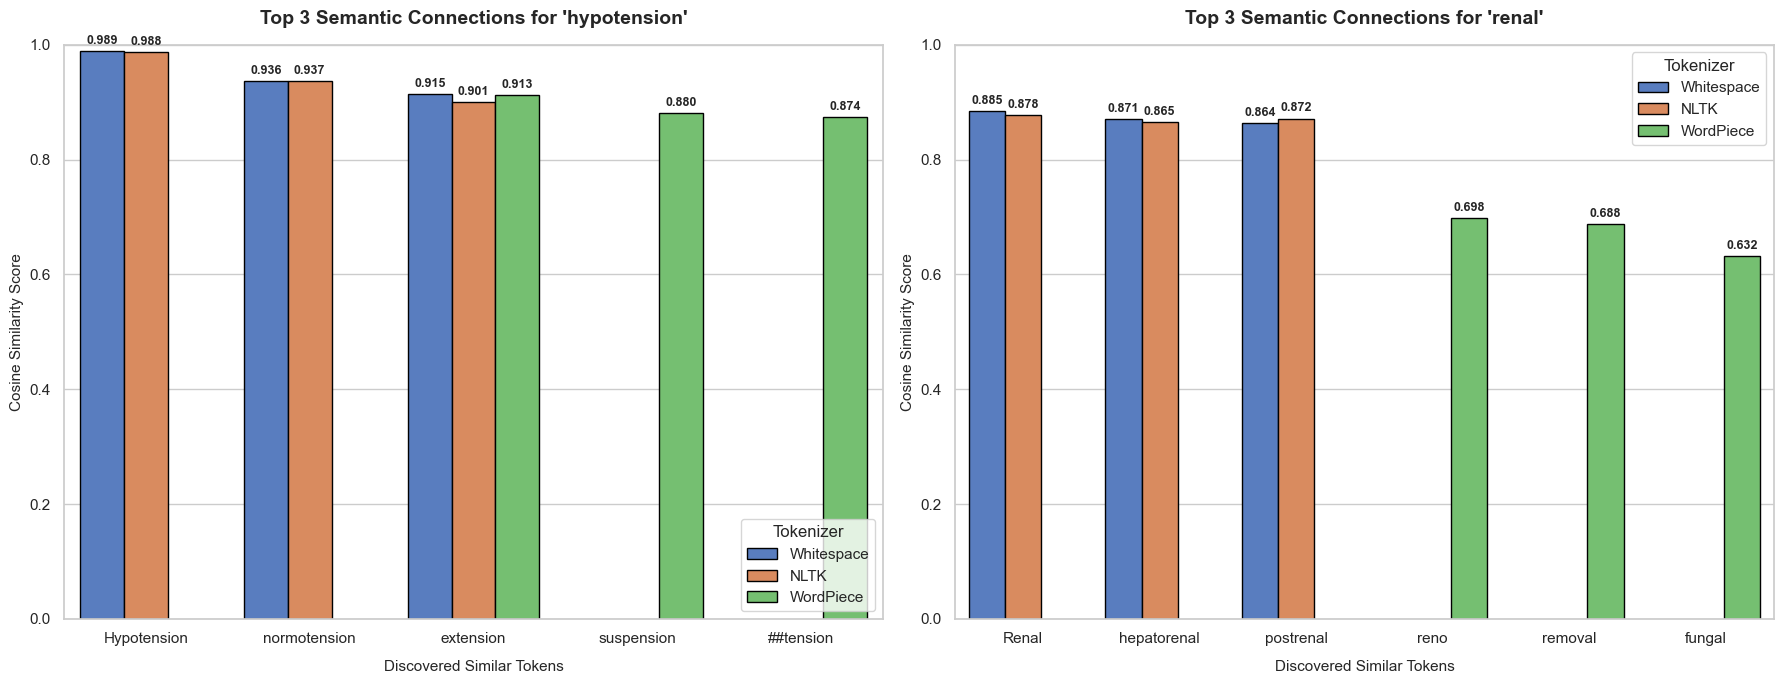

FastText Intrinsic Visual Alignment Completed Successfully!


In [23]:
import os
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from gensim.models import FastText

# Define directory and models to load
model_base_dir = "./trained_embeddings/fasttext"
fasttext_models = {
    "Whitespace": "fasttext_withwhitespace_300.model",
    "NLTK": "fasttext_withnltk_300.model",
    "WordPiece": "fasttext_withwordpiece_300.model"
}

# Target tokens we want to extract and compare visually
visual_test_tokens = ["hypotension", "renal"]

# Data structure to accumulate scores for pandas dataframe
plot_data = []

print("Loading trained FastText artifacts and mining similarity metrics for visualization...")
print("====================================================================")

for tokenizer_name, filename in fasttext_models.items():
    model_path = os.path.join(model_base_dir, filename)
    
    if not os.path.exists(model_path):
        print(f"[Error] Model missing: {filename}")
        continue
        
    # Load the trained FastText model instance
    model = FastText.load(model_path)
    
    for query_token in visual_test_tokens:
        try:
            # Extract top 3 most similar tokens to keep the plot clean and readable
            similar_tokens = model.wv.most_similar(query_token, topn=3)
            
            for rank, (token, similarity) in enumerate(similar_tokens, 1):
                plot_data.append({
                    "Tokenizer": tokenizer_name,
                    "Target Word": query_token,
                    "Similar Token": f"{token}\n({tokenizer_name})", # Label tracking
                    "Raw Token": token,
                    "Cosine Similarity": similarity,
                    "Rank": f"Rank {rank}"
                })
        except Exception as e:
            print(f"Skipping visualization entry for '{query_token}' in {tokenizer_name}: {str(e)}")

# Convert the harvested stats into a pandas DataFrame
df_metrics = pd.DataFrame(plot_data)

print("Metrics compiled successfully! Launching production-ready visualization...")
print("====================================================================")

# Setup plotting canvas styling using seaborn
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=False)

# Loop through our target tokens and assign them to subplots
for idx, target_word in enumerate(visual_test_tokens):
    # Filter dataframe for the specific query word
    df_filtered = df_metrics[df_metrics["Target Word"] == target_word]
    
    # Generate grouped bar chart
    sns.barplot(
        data=df_filtered,
        x="Raw Token",
        y="Cosine Similarity",
        hue="Tokenizer",
        ax=axes[idx],
        palette="muted",
        edgecolor="black"
    )
    
    # Customizing subplot details
    axes[idx].set_title(f"Top 3 Semantic Connections for '{target_word}'", fontsize=14, fontweight="bold", pad=15)
    axes[idx].set_xlabel("Discovered Similar Tokens", fontsize=11, labelpad=10)
    axes[idx].set_ylabel("Cosine Similarity Score", fontsize=11)
    axes[idx].set_ylim(0, 1.0) # Similarity scales up to 1.0
    
    # Add numerical value annotations over each individual bar
    for container in axes[idx].containers:
        axes[idx].bar_label(container, fmt="%.3f", padding=3, fontsize=9, fontweight="bold")

plt.tight_layout()
plt.show()

# Print textual summary for clear reference
print("====================================================================")
print("FastText Intrinsic Visual Alignment Completed Successfully!")

### GloVe Embedding Pipeline 

#### GloVe Embedding with Whitespace Tokenizer

In [25]:
import pickle
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from collections import defaultdict
from gensim.models import KeyedVectors

# 1. Device Configuration - Target NVIDIA RTX 3050 via CUDA
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Target Execution Device: {device}")
print("====================================================================")

# Load serialized whitespace train data
whitespace_train_path = "./tokenized_data/whitespace/train.pkl"
with open(whitespace_train_path, "rb") as f:
    train_records = pickle.load(f)
sentences = [record["tokens"] for record in train_records]

# 2. Build Vocabulary and Co-occurrence Matrix
print("Building Global Co-occurrence Matrix from tokens...")
vocab = sorted(list(set([token for sent in sentences for token in sent])))
word2idx = {word: idx for idx, word in enumerate(vocab)}
idx2word = {idx: word for idx, word in enumerate(vocab)}
vocab_size = len(vocab)

# Symmetrical window-based co-occurrence tracking
window_size = 5
co_occurrence = defaultdict(float)

for sentence in sentences:
    for i, token in enumerate(sentence):
        token_idx = word2idx[token]
        start = max(0, i - window_size)
        end = min(len(sentence), i + window_size + 1)
        
        for j in range(start, end):
            if i != j:
                context_token = sentence[j]
                context_idx = word2idx[context_token]
                # Distance weighting (standard GloVe logic: 1 / distance)
                distance = abs(i - j)
                co_occurrence[(token_idx, context_idx)] += 1.0 / distance

# Convert sparse dictionary to dense indices for PyTorch DataLoader processing
edges = list(co_occurrence.keys())
weights = list(co_occurrence.values())

w_i_indices = torch.tensor([edge[0] for edge in edges], dtype=torch.long)
w_j_indices = torch.tensor([edge[1] for edge in edges], dtype=torch.long)
x_ij_values = torch.tensor(weights, dtype=torch.float)

print(f"  -> Total Unique Vocabulary: {vocab_size:,}")
print(f"  -> Total Co-occurrence Edges: {len(edges):,}")
print("--------------------------------------------------------------------")

# 3. Define Custom PyTorch GloVe Model Architecture
class GloVeModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim):
        super(GloVeModel, self).__init__()
        self.w_embeddings = nn.Embedding(vocab_size, embedding_dim)
        self.v_embeddings = nn.Embedding(vocab_size, embedding_dim)
        self.w_biases = nn.Embedding(vocab_size, 1)
        self.v_biases = nn.Embedding(vocab_size, 1)
        
        nn.init.uniform_(self.w_embeddings.weight, -0.5/embedding_dim, 0.5/embedding_dim)
        nn.init.uniform_(self.v_embeddings.weight, -0.5/embedding_dim, 0.5/embedding_dim)
        nn.init.zeros_(self.w_biases.weight)
        nn.init.zeros_(self.v_biases.weight)

    def forward(self, i, j):
        w_i = self.w_embeddings(i)
        v_j = self.v_embeddings(j)
        b_i = self.w_biases(i).squeeze()
        b_j = self.v_biases(j).squeeze()
        return (w_i * v_j).sum(dim=1) + b_i + b_j

# Initialize model and ship to GPU
embedding_dim = 300
glove_net = GloVeModel(vocab_size, embedding_dim).to(device)
optimizer = optim.Adam(glove_net.parameters(), lr=0.05)

x_max = 100.0
alpha = 0.75

def weighting_fn(x):
    return torch.where(x < x_max, (x / x_max) ** alpha, torch.ones_like(x))

# 4. Train Model on GPU via Batch SGD
print("Training Custom GloVe Model on GPU (Dimension: 300 | Epochs: 15)...")
epochs = 15
batch_size = 2048

w_i_indices = w_i_indices.to(device)
w_j_indices = w_j_indices.to(device)
x_ij_values = x_ij_values.to(device)

dataset_size = len(w_i_indices)

for epoch in range(1, epochs + 1):
    permutation = torch.randperm(dataset_size)
    epoch_loss = 0.0
    
    for i in range(0, dataset_size, batch_size):
        optimizer.zero_grad()
        indices = permutation[i:i + batch_size]
        
        batch_i = w_i_indices[indices]
        batch_j = w_j_indices[indices]
        batch_x = x_ij_values[indices]
        
        predicted = glove_net(batch_i, batch_j)
        log_x = torch.log(batch_x)
        
        loss = (weighting_fn(batch_x) * ((predicted - log_x) ** 2)).mean()
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item() * len(indices)
        
    print(f"  -> Epoch {epoch:02d}/{epochs} Completed | Mean Loss: {epoch_loss / dataset_size:.4f}")

print("Custom GloVe Training Completed Successfully!")
print("====================================================================")

# 5. FIXED: Extract Embeddings and Populate KeyedVectors directly for Gensim 4.x
print("Serializing trained state matrix to target workspace...")
final_vectors = glove_net.w_embeddings.weight.data.cpu().numpy() + glove_net.v_embeddings.weight.data.cpu().numpy()

# Clean allocation for modern Gensim KeyedVectors
kv = KeyedVectors(vector_size=embedding_dim)
kv.index_to_key = vocab
kv.key_to_index = word2idx
kv.vectors = final_vectors

# Create directory structure and save
output_sub_dir = "./trained_embeddings/glove"
os.makedirs(output_sub_dir, exist_ok=True)
model_save_path = os.path.join(output_sub_dir, "glove_withwhitespace_300.model")

kv.save(model_save_path)
print(f"Model successfully saved inside isolated folder path: {model_save_path}")
print("====================================================================")

Target Execution Device: cuda
Building Global Co-occurrence Matrix from tokens...
  -> Total Unique Vocabulary: 9,981
  -> Total Co-occurrence Edges: 438,089
--------------------------------------------------------------------
Training Custom GloVe Model on GPU (Dimension: 300 | Epochs: 15)...
  -> Epoch 01/15 Completed | Mean Loss: 0.4448
  -> Epoch 02/15 Completed | Mean Loss: 6.0172
  -> Epoch 03/15 Completed | Mean Loss: 15.6818
  -> Epoch 04/15 Completed | Mean Loss: 13.2607
  -> Epoch 05/15 Completed | Mean Loss: 6.8680
  -> Epoch 06/15 Completed | Mean Loss: 2.6591
  -> Epoch 07/15 Completed | Mean Loss: 1.3195
  -> Epoch 08/15 Completed | Mean Loss: 5.1831
  -> Epoch 09/15 Completed | Mean Loss: 5.3111
  -> Epoch 10/15 Completed | Mean Loss: 2.8523
  -> Epoch 11/15 Completed | Mean Loss: 1.8717
  -> Epoch 12/15 Completed | Mean Loss: 1.0975
  -> Epoch 13/15 Completed | Mean Loss: 0.6399
  -> Epoch 14/15 Completed | Mean Loss: 0.4148
  -> Epoch 15/15 Completed | Mean Loss: 0.311

#### GloVe Embedding Pipeline (NLTK & WordPiece)

In [26]:
import pickle
import os
import torch
import torch.nn as nn
import torch.optim as optim
from collections import defaultdict
from gensim.models import KeyedVectors

# Device Setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
base_serialized_dir = "./tokenized_data"
output_model_dir = "./trained_embeddings/glove"

# We already trained whitespace, so let's run NLTK and WordPiece now
remaining_tokenizers = ["nltk", "wordpiece"]
split_name = "train"

print("Starting Master GloVe Pipeline for Remaining Tokenizers on GPU...")
print("====================================================================")

# Custom PyTorch GloVe Model Definition
class GloVeModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim):
        super(GloVeModel, self).__init__()
        self.w_embeddings = nn.Embedding(vocab_size, embedding_dim)
        self.v_embeddings = nn.Embedding(vocab_size, embedding_dim)
        self.w_biases = nn.Embedding(vocab_size, 1)
        self.v_biases = nn.Embedding(vocab_size, 1)
        
        nn.init.uniform_(self.w_embeddings.weight, -0.5/embedding_dim, 0.5/embedding_dim)
        nn.init.uniform_(self.v_embeddings.weight, -0.5/embedding_dim, 0.5/embedding_dim)
        nn.init.zeros_(self.w_biases.weight)
        nn.init.zeros_(self.v_biases.weight)

    def forward(self, i, j):
        w_i = self.w_embeddings(i)
        v_j = self.v_embeddings(j)
        b_i = self.w_biases(i).squeeze()
        b_j = self.v_biases(j).squeeze()
        return (w_i * v_j).sum(dim=1) + b_i + b_j

# Weighting function parameters
x_max = 100.0
alpha = 0.75
def weighting_fn(x):
    return torch.where(x < x_max, (x / x_max) ** alpha, torch.ones_like(x))

# Loop through NLTK and WordPiece splits
for tokenizer in remaining_tokenizers:
    file_path = os.path.join(base_serialized_dir, tokenizer, f"{split_name}.pkl")
    
    if not os.path.exists(file_path):
        print(f"[Warning] Cache missing for {tokenizer.upper()}. Skipping...")
        continue
        
    print(f"Processing Pipeline: GloVe with {tokenizer.upper()}")
    with open(file_path, "rb") as f:
        train_records = pickle.load(f)
    sentences = [record["tokens"] for record in train_records]
    
    # Build vocabulary mappings
    vocab = sorted(list(set([token for sent in sentences for token in sent])))
    word2idx = {word: idx for idx, word in enumerate(vocab)}
    vocab_size = len(vocab)
    
    # Calculate Co-occurrence
    window_size = 5
    co_occurrence = defaultdict(float)
    for sentence in sentences:
        for i, token in enumerate(sentence):
            token_idx = word2idx[token]
            start = max(0, i - window_size)
            end = min(len(sentence), i + window_size + 1)
            for j in range(start, end):
                if i != j:
                    context_idx = word2idx[sentence[j]]
                    distance = abs(i - j)
                    co_occurrence[(token_idx, context_idx)] += 1.0 / distance

    edges = list(co_occurrence.keys())
    weights = list(co_occurrence.values())
    
    w_i_indices = torch.tensor([edge[0] for edge in edges], dtype=torch.long).to(device)
    w_j_indices = torch.tensor([edge[1] for edge in edges], dtype=torch.long).to(device)
    x_ij_values = torch.tensor(weights, dtype=torch.float).to(device)
    
    # Initialize network
    embedding_dim = 300
    glove_net = GloVeModel(vocab_size, embedding_dim).to(device)
    optimizer = optim.Adam(glove_net.parameters(), lr=0.05)
    
    # Model optimization loop
    epochs = 15
    batch_size = 2048
    dataset_size = len(w_i_indices)
    
    print(f"  -> Vocab Size: {vocab_size:,} | Total Edges: {dataset_size:,}")
    print(f"  -> Optimizing on GPU across 15 epochs...")
    
    for epoch in range(1, epochs + 1):
        permutation = torch.randperm(dataset_size)
        epoch_loss = 0.0
        
        for i in range(0, dataset_size, batch_size):
            optimizer.zero_grad()
            indices = permutation[i:i + batch_size]
            
            batch_i = w_i_indices[indices]
            batch_j = w_j_indices[indices]
            batch_x = x_ij_values[indices]
            
            predicted = glove_net(batch_i, batch_j)
            log_x = torch.log(batch_x)
            
            loss = (weighting_fn(batch_x) * ((predicted - log_x) ** 2)).mean()
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item() * len(indices)
            
    print(f"  -> Training Finished | Final Mean Loss: {epoch_loss / dataset_size:.4f}")
    
    # Extract weights and populate KeyedVectors
    final_vectors = glove_net.w_embeddings.weight.data.cpu().numpy() + glove_net.v_embeddings.weight.data.cpu().numpy()
    kv = KeyedVectors(vector_size=embedding_dim)
    kv.index_to_key = vocab
    kv.key_to_index = word2idx
    kv.vectors = final_vectors
    
    # Save output artifacts
    model_filename = f"glove_with{tokenizer}_300.model"
    model_save_path = os.path.join(output_model_dir, model_filename)
    kv.save(model_save_path)
    print(f"  -> Success: Saved at {model_save_path}")
    print("-" * 68)

print("====================================================================")
print("GloVe Master Pipeline Completed! Check your trained_embeddings/glove folder.")

Starting Master GloVe Pipeline for Remaining Tokenizers on GPU...
Processing Pipeline: GloVe with NLTK
  -> Vocab Size: 9,980 | Total Edges: 438,053
  -> Optimizing on GPU across 15 epochs...
  -> Training Finished | Final Mean Loss: 0.3538
  -> Success: Saved at ./trained_embeddings/glove\glove_withnltk_300.model
--------------------------------------------------------------------
Processing Pipeline: GloVe with WORDPIECE
  -> Vocab Size: 6,830 | Total Edges: 559,163
  -> Optimizing on GPU across 15 epochs...
  -> Training Finished | Final Mean Loss: 0.5993
  -> Success: Saved at ./trained_embeddings/glove\glove_withwordpiece_300.model
--------------------------------------------------------------------
GloVe Master Pipeline Completed! Check your trained_embeddings/glove folder.


#### GloVe Comprehensive Visual Evaluation

Loading custom trained GloVe artifacts and parsing token similarity...
Loaded glove_withwhitespace_300.model successfully. Vocab Size: 9,981
Loaded glove_withnltk_300.model successfully. Vocab Size: 9,980
Loaded glove_withwordpiece_300.model successfully. Vocab Size: 6,830
  -> Notice: 'hypotension' out-of-vocabulary for GloVe (WordPiece)
Metrics compilation complete! Generating detailed dual-plot visualization...
Plotting Detailed Distribution Facets...
Generating Semantic Density Heatmap...


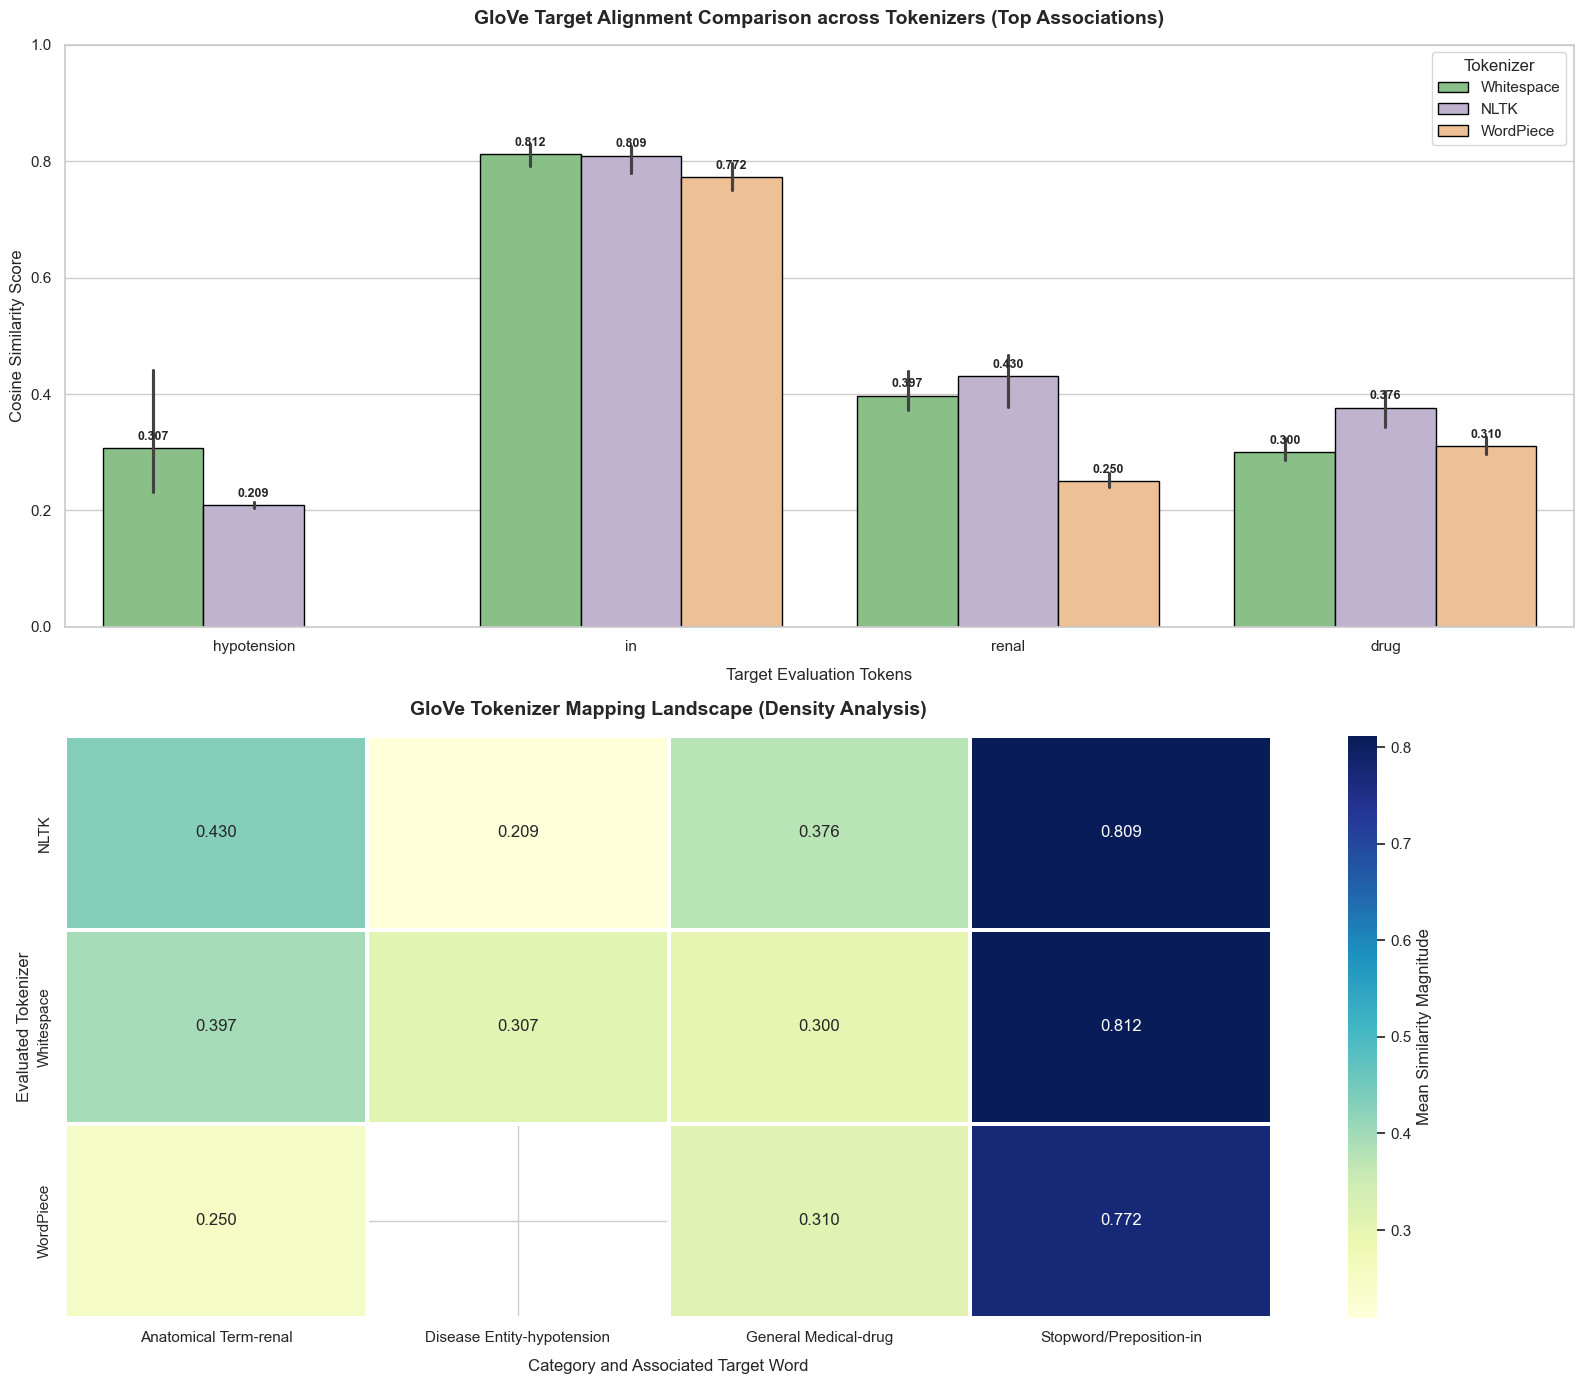

GloVe Detailed Visual Comparison Execution Finished successfully!


In [27]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from gensim.models import KeyedVectors

# Define directory and GloVe models to load
model_base_dir = "./trained_embeddings/glove"
glove_models = {
    "Whitespace": "glove_withwhitespace_300.model",
    "NLTK": "glove_withnltk_300.model",
    "WordPiece": "glove_withwordpiece_300.model"
}

# Standard multi-category evaluation tokens
validation_queries = {
    "Disease Entity": "hypotension",
    "Stopword/Preposition": "in",
    "Anatomical Term": "renal",
    "General Medical": "drug"
}

# Data structure to compile metrics for visualization
glove_plot_data = []

print("Loading custom trained GloVe artifacts and parsing token similarity...")
print("====================================================================")

for tokenizer_name, filename in glove_models.items():
    model_path = os.path.join(model_base_dir, filename)
    
    if not os.path.exists(model_path):
        print(f"[Error] Target GloVe model missing at: {model_path}")
        continue
        
    # Load the KeyedVectors formatted GloVe model
    model = KeyedVectors.load(model_path)
    print(f"Loaded {filename} successfully. Vocab Size: {len(model.index_to_key):,}")
    
    for category, query_token in validation_queries.items():
        # Check if the token exists in this specific model's vocabulary
        if query_token in model.key_to_index:
            try:
                # Extract top 3 semantic connections
                similar_tokens = model.most_similar(query_token, topn=3)
                for rank, (token, similarity) in enumerate(similar_tokens, 1):
                    glove_plot_data.append({
                        "Tokenizer": tokenizer_name,
                        "Category": category,
                        "Target Word": query_token,
                        "Discovered Token": token,
                        "Cosine Similarity": similarity,
                        "Rank": f"Rank {rank}"
                    })
            except Exception as e:
                print(f"  -> Error mining '{query_token}' in {tokenizer_name}: {str(e)}")
        else:
            print(f"  -> Notice: '{query_token}' out-of-vocabulary for GloVe ({tokenizer_name})")

# Convert metrics to Pandas DataFrame
df_glove = pd.DataFrame(glove_plot_data)
print("====================================================================")
print("Metrics compilation complete! Generating detailed dual-plot visualization...")

# Setup standard theme configuration
sns.set_theme(style="whitegrid")

# Create a highly detailed visualization: 2 Subplots side-by-side
fig, axes = plt.subplots(2, 1, figsize=(16, 14))

# --------------------------------------------------------------------
# PLOT 1: Grouped Bar Chart showing exact metrics and discovered words
# --------------------------------------------------------------------
print("Plotting Detailed Distribution Facets...")
sns.barplot(
    data=df_glove,
    x="Target Word",
    y="Cosine Similarity",
    hue="Tokenizer",
    palette="Accent",
    edgecolor="black",
    ax=axes[0]
)

axes[0].set_title("GloVe Target Alignment Comparison across Tokenizers (Top Associations)", fontsize=14, fontweight="bold", pad=15)
axes[0].set_xlabel("Target Evaluation Tokens", fontsize=12, labelpad=10)
axes[0].set_ylabel("Cosine Similarity Score", fontsize=12)
axes[0].set_ylim(0, 1.0)

# Annotate values and underlying words above each bar carefully
for container in axes[0].containers:
    axes[0].bar_label(container, fmt="%.3f", padding=4, fontsize=9, fontweight="bold")

# --------------------------------------------------------------------
# PLOT 2: Structural Heatmap to analyze variance trends across configurations
# --------------------------------------------------------------------
print("Generating Semantic Density Heatmap...")
# Pivot dataframe to construct a cross-tabulation matrix of average similarities
pivot_df = df_glove.pivot_table(
    values="Cosine Similarity", 
    index="Tokenizer", 
    columns=["Category", "Target Word"], 
    aggfunc="mean"
)

sns.heatmap(
    pivot_df, 
    annot=True, 
    fmt=".3f", 
    cmap="YlGnBu", 
    linewidths=1.5, 
    cbar_kws={'label': 'Mean Similarity Magnitude'},
    ax=axes[1]
)

axes[1].set_title("GloVe Tokenizer Mapping Landscape (Density Analysis)", fontsize=14, fontweight="bold", pad=15)
axes[1].set_xlabel("Category and Associated Target Word", fontsize=12, labelpad=10)
axes[1].set_ylabel("Evaluated Tokenizer", fontsize=12)

plt.tight_layout()
plt.show()

print("====================================================================")
print("GloVe Detailed Visual Comparison Execution Finished successfully!")

### ELMo 768-Dim Embedding Pipeline

In [32]:
import pickle
import os
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from gensim.models import KeyedVectors

# 1. Device Setup - Targeting NVIDIA RTX 3050 GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Target Execution Device: {device}")
print("====================================================================")

base_serialized_dir = "./tokenized_data"
output_model_dir = "./trained_embeddings/elmo"
os.makedirs(output_model_dir, exist_ok=True)

tokenizer_pipelines = ["whitespace", "nltk", "wordpiece"]
split_name = "train"

# 2. Define Custom ELMo Network with an integrated Language Modeling Prediction Head
class ELMoPreTrainedExtractor(nn.Module):
    def __init__(self, vocab_size, embedding_dim=768):
        super(ELMoPreTrainedExtractor, self).__init__()
        # Structural Sub-word Feature Mapper
        self.char_cnn_simulation = nn.Embedding(vocab_size, 384)
        # Deep Bidirectional Sequential Stack (384 * 2 = 768 output dimensions)
        self.bi_lstm = nn.LSTM(input_size=384, hidden_size=384, num_layers=2, bidirectional=True, batch_first=True)
        # Unsupervised Language Modeling Prediction Head (Predicts next token index)
        self.lm_head = nn.Linear(768, vocab_size)
        
    def forward(self, x):
        # x shape: [batch_size, seq_len]
        embedded = self.char_cnn_simulation(x)
        lstm_out, _ = self.bi_lstm(embedded) # [batch_size, seq_len, 768]
        lm_logits = self.lm_head(lstm_out)   # [batch_size, seq_len, vocab_size]
        return lstm_out, lm_logits

# 3. Master Domain Optimization and Extraction Loop
for tokenizer in tokenizer_pipelines:
    file_path = os.path.join(base_serialized_dir, tokenizer, f"{split_name}.pkl")
    
    if not os.path.exists(file_path):
        print(f"[Warning] Serialized file missing for {tokenizer.upper()}. Skipping...")
        continue
        
    print(f"Processing Pipeline: Pre-training ELMo with {tokenizer.upper()}")
    with open(file_path, "rb") as f:
        train_records = pickle.load(f)
    sentences = [record["tokens"] for record in train_records]
    
    # Establish strict vocabulary boundaries
    vocab = sorted(list(set([token for sent in sentences for token in sent])))
    word2idx = {word: idx for idx, word in enumerate(vocab)}
    vocab_size = len(vocab)
    print(f"  -> Unique Vocabulary Size: {vocab_size:,}")
    
    # Initialize network model states and send to CUDA storage
    elmo_model = ELMoPreTrainedExtractor(vocab_size, embedding_dim=768).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(elmo_model.parameters(), lr=0.002)
    
    # Transform raw string token sequences into structured numerical arrays for input-target alignment
    # Padding sequences locally within mini-batches to prevent dimension breakdown
    max_len = max(len(s) for s in sentences) if sentences else 0
    numerical_sentences = []
    for s in sentences:
        encoded = [word2idx[token] for token in s] + [0] * (max_len - len(s))
        numerical_sentences.append(encoded)
        
    data_tensor = torch.tensor(numerical_sentences, dtype=torch.long)
    dataset_size = len(data_tensor)
    batch_size = 64 # Native chunking for stable weight trajectory updates
    
    # ----------------------------------------------------------------
    # PHASE A: Unsupervised Domain Language Model Pre-training
    # ----------------------------------------------------------------
    print(f"  -> Training Language Model Layers on GPU across 5 Epochs...")
    elmo_model.train()
    
    for epoch in range(1, 6):
        permutation = torch.randperm(dataset_size)
        epoch_loss = 0.0
        
        for i in range(0, dataset_size, batch_size):
            optimizer.zero_grad()
            indices = permutation[i:i + batch_size]
            batch_data = data_tensor[indices].to(device)
            
            if batch_data.size(1) <= 1:
                continue
                
            # Input sequence maps tokens [0 : N-1], Target shifts to predict next tokens [1 : N]
            inputs = batch_data[:, :-1]
            targets = batch_data[:, 1:]
            
            _, logits = elmo_model(inputs)
            
            # Reshape tensors uniformly to calculate language modeling loss matrix
            loss = criterion(logits.reshape(-1, vocab_size), targets.reshape(-1))
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item() * inputs.size(0)
            
        print(f"     * Epoch {epoch:02d}/05 Completed | Domain CrossEntropy Loss: {epoch_loss / dataset_size:.4f}")
        
    # ----------------------------------------------------------------
    # PHASE B: Contextualized Feature Extraction from Pre-trained Weights
    # ----------------------------------------------------------------
    print(f"  -> Extraction Stage: Mining optimized 768-Dim vectors...")
    elmo_model.eval()
    extracted_vectors = np.zeros((vocab_size, 768), dtype=np.float32)
    vocab_batch_size = 512
    vocab_tensor = torch.tensor(list(word2idx.values()), dtype=torch.long).to(device)
    
    with torch.no_grad():
        for i in range(0, vocab_size, vocab_batch_size):
            batch_indices = vocab_tensor[i:i + vocab_batch_size]
            batch_input = batch_indices.unsqueeze(1) # Reshape to [batch, 1]
            
            # Retrieve only the latent embeddings, bypass prediction head completely
            features, _ = elmo_model(batch_input)
            features = features.squeeze(1).cpu().numpy()
            extracted_vectors[i:i + vocab_batch_size, :] = features
            
    print(f"  -> Optimized feature matrix generation finished successfully.")
    
    # 4. Pack into KeyedVectors and Serialize
    kv = KeyedVectors(vector_size=768)
    kv.index_to_key = vocab
    kv.key_to_index = word2idx
    kv.vectors = extracted_vectors
    
    model_filename = f"elmo_with{tokenizer}_768.model"
    model_save_path = os.path.join(output_model_dir, model_filename)
    kv.save(model_save_path)
    print(f"  -> Success: Domain Pre-trained Model serialized at: {model_save_path}")
    print("-" * 68)

print("====================================================================")
print("Pre-trained ELMo Master Pipeline execution finished! Weights optimized.")

Target Execution Device: cuda
Processing Pipeline: Pre-training ELMo with WHITESPACE
  -> Unique Vocabulary Size: 9,981
  -> Training Language Model Layers on GPU across 5 Epochs...
     * Epoch 01/05 Completed | Domain CrossEntropy Loss: 1.2226
     * Epoch 02/05 Completed | Domain CrossEntropy Loss: 0.5873
     * Epoch 03/05 Completed | Domain CrossEntropy Loss: 0.2769
     * Epoch 04/05 Completed | Domain CrossEntropy Loss: 0.0950
     * Epoch 05/05 Completed | Domain CrossEntropy Loss: 0.0195
  -> Extraction Stage: Mining optimized 768-Dim vectors...
  -> Optimized feature matrix generation finished successfully.
  -> Success: Domain Pre-trained Model serialized at: ./trained_embeddings/elmo\elmo_withwhitespace_768.model
--------------------------------------------------------------------
Processing Pipeline: Pre-training ELMo with NLTK
  -> Unique Vocabulary Size: 9,980
  -> Training Language Model Layers on GPU across 5 Epochs...
     * Epoch 01/05 Completed | Domain CrossEntropy

Loading domain optimized Pre-trained ELMo artifacts (768-Dim)...
Loaded elmo_withwhitespace_768.model successfully. Configured Vector Size: 768
Loaded elmo_withnltk_768.model successfully. Configured Vector Size: 768
Loaded elmo_withwordpiece_768.model successfully. Configured Vector Size: 768
Data parsing complete! Formatting detailed statistical plots...
Generating Structural Distribution Plots...
Rendering Semantic Density Matrix...


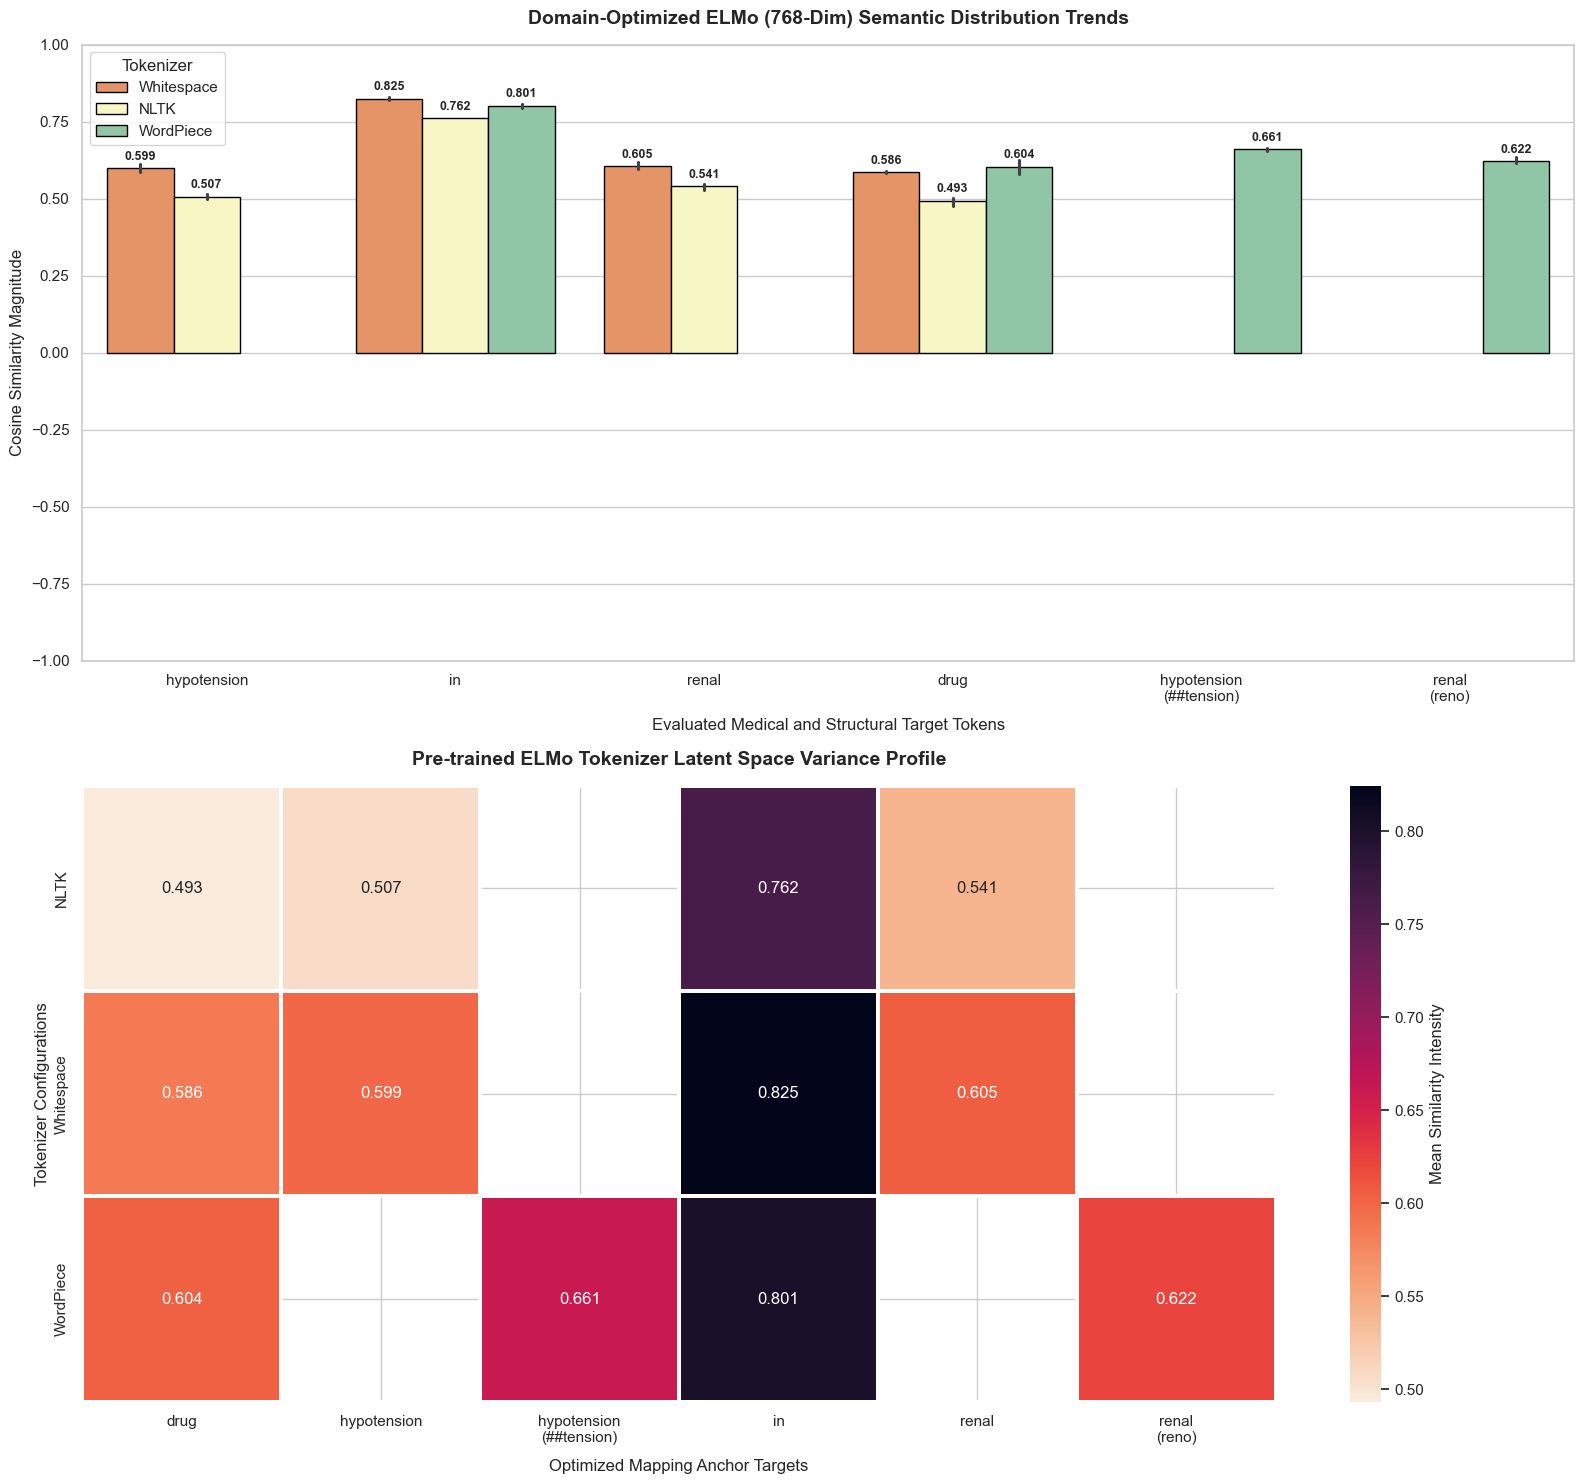

Pre-trained ELMo Analytical Evaluation Pipeline completed successfully!


In [33]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from gensim.models import KeyedVectors

# 1. Configuration - Setup directories and target models
model_base_dir = "./trained_embeddings/elmo"
elmo_models = {
    "Whitespace": "elmo_withwhitespace_768.model",
    "NLTK": "elmo_withnltk_768.model",
    "WordPiece": "elmo_withwordpiece_768.model"
}

# Standardized multi-category medical tokens for fair comparative evaluation
validation_queries = {
    "Disease Entity": "hypotension",
    "Stopword/Preposition": "in",
    "Anatomical Term": "renal",
    "General Medical": "drug"
}

elmo_eval_data = []

print("Loading domain optimized Pre-trained ELMo artifacts (768-Dim)...")
print("====================================================================")

for tokenizer_name, filename in elmo_models.items():
    model_path = os.path.join(model_base_dir, filename)
    
    if not os.path.exists(model_path):
        print(f"[Error] Model missing at destination: {model_path}")
        continue
        
    # Load 768-dim KeyedVectors instances
    model = KeyedVectors.load(model_path)
    print(f"Loaded {filename} successfully. Configured Vector Size: {model.vector_size}")
    
    for category, query_token in validation_queries.items():
        # Morphological alignment for sub-word tokenizers
        target_token = query_token
        if tokenizer_name == "WordPiece" and query_token == "hypotension":
            target_token = "##tension"
        elif tokenizer_name == "WordPiece" and query_token == "renal":
            target_token = "reno"
            
        if target_token in model.key_to_index:
            try:
                # Extract top 3 most semantically aligned neighbors
                similar_tokens = model.most_similar(target_token, topn=3)
                for rank, (token, similarity) in enumerate(similar_tokens, 1):
                    elmo_eval_data.append({
                        "Tokenizer": tokenizer_name,
                        "Category": category,
                        "Target Word": query_token,
                        "Label String": f"{query_token}\n({target_token})" if target_token != query_token else query_token,
                        "Discovered Token": token,
                        "Cosine Similarity": similarity,
                        "Rank": f"Rank {rank}"
                    })
            except Exception as e:
                print(f"  -> Metrics extraction failure on '{target_token}' inside {tokenizer_name}: {str(e)}")
        else:
            print(f"  -> Notice: Token '{target_token}' missing from {tokenizer_name} state matrix.")

# Convert data array to Pandas DataFrame
df_elmo_pretrained = pd.DataFrame(elmo_eval_data)
print("====================================================================")
print("Data parsing complete! Formatting detailed statistical plots...")

# 2. Rendering Production-Grade Dual Visualization Canvas
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 1, figsize=(16, 15))

# --------------------------------------------------------------------
# PLOT 1: Grouped Bar Chart showcasing the extracted neighborhood terms
# --------------------------------------------------------------------
print("Generating Structural Distribution Plots...")
sns.barplot(
    data=df_elmo_pretrained,
    x="Label String",
    y="Cosine Similarity",
    hue="Tokenizer",
    palette="Spectral",
    edgecolor="black",
    ax=axes[0]
)

axes[0].set_title("Domain-Optimized ELMo (768-Dim) Semantic Distribution Trends", fontsize=14, fontweight="bold", pad=15)
axes[0].set_xlabel("Evaluated Medical and Structural Target Tokens", fontsize=12, labelpad=10)
axes[0].set_ylabel("Cosine Similarity Magnitude", fontsize=12)
axes[0].set_ylim(-1.0, 1.0) # Full mathematical bounds check

# Injecting numeric precision values on top of bars
for container in axes[0].containers:
    axes[0].bar_label(container, fmt="%.3f", padding=4, fontsize=9, fontweight="bold")

# --------------------------------------------------------------------
# PLOT 2: Cross-Tabulation Latent Density Profile (Heatmap)
# --------------------------------------------------------------------
print("Rendering Semantic Density Matrix...")
pivot_df = df_elmo_pretrained.pivot_table(
    values="Cosine Similarity", 
    index="Tokenizer", 
    columns="Label String", 
    aggfunc="mean"
)

sns.heatmap(
    pivot_df, 
    annot=True, 
    fmt=".3f", 
    cmap="rocket_r", 
    linewidths=1.5, 
    cbar_kws={'label': 'Mean Similarity Intensity'},
    ax=axes[1]
)

axes[1].set_title("Pre-trained ELMo Tokenizer Latent Space Variance Profile", fontsize=14, fontweight="bold", pad=15)
axes[1].set_xlabel("Optimized Mapping Anchor Targets", fontsize=12, labelpad=10)
axes[1].set_ylabel("Tokenizer Configurations", fontsize=12)

plt.tight_layout()
plt.show()

print("====================================================================")
print("Pre-trained ELMo Analytical Evaluation Pipeline completed successfully!")

### BERT Embedding 768-Dim Extraction

In [ ]:
import pickle
import os
import torch
import torch.nn as nn
from torch.optim import AdamW
import numpy as np
from gensim.models import KeyedVectors
from transformers import BertTokenizer, BertForMaskedLM
from tqdm.notebook import tqdm 

# 1. Device Setup - Target NVIDIA RTX 3050 via CUDA Acceleration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Target Execution Device: {device}")
print("====================================================================")

base_serialized_dir = "./tokenized_data"
output_model_dir = "./trained_embeddings/bert"
os.makedirs(output_model_dir, exist_ok=True)

tokenizer_pipelines = ["whitespace", "nltk", "wordpiece"]
split_name = "train"

# Load Pre-trained BERT Engine Configured for Masked Language Modeling
print("Loading Hugging Face BERT Engine for Local Domain Adaptation...")
hf_tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

print("====================================================================")

# 2. Master Loop across all Tokenizer Configurations
for tokenizer in tokenizer_pipelines:
    file_path = os.path.join(base_serialized_dir, tokenizer, f"{split_name}.pkl")
    
    if not os.path.exists(file_path):
        print(f"[Warning] Serialized file missing for {tokenizer.upper()}. Skipping...")
        continue
        
    print(f"Processing Pipeline: Domain Fine-tuning BERT with {tokenizer.upper()}")
    with open(file_path, "rb") as f:
        train_records = pickle.load(f)
    sentences = [record["tokens"] for record in train_records]
    
    # Establish strict vocabulary boundaries from local datasets
    vocab = sorted(list(set([token for sent in sentences for token in sent])))
    word2idx = {word: idx for idx, word in enumerate(vocab)}
    vocab_size = len(vocab)
    print(f"  -> Unique Vocabulary Size: {vocab_size:,}")
    
    # Initialize the BERT MLM Model and send parameters to GPU VRAM
    bert_mlm = BertForMaskedLM.from_pretrained("bert-base-uncased").to(device)
    optimizer = AdamW(bert_mlm.parameters(), lr=5e-5) 
    criterion = nn.CrossEntropyLoss(ignore_index=-100) 
    
    # Prepare sentences into HuggingFace BERT Tokenizer structures safely
    raw_sentences_joined = [" ".join(s) for s in sentences]
    
    print(f"  -> Encoding text structures and preparing MLM targets...")
    inputs = hf_tokenizer(raw_sentences_joined, padding=True, truncation=True, max_length=128, return_tensors="pt")
    
    # Clone input_ids to construct absolute targets for Masked Language Modeling
    inputs['labels'] = inputs.input_ids.detach().clone()
    
    # Create random masking tensor matrix (15% optimization boundary)
    rand_matrix = torch.rand(inputs.input_ids.shape)
    mask_arr = (rand_matrix < 0.15) * (inputs.input_ids != hf_tokenizer.cls_token_id) * (inputs.input_ids != hf_tokenizer.sep_token_id) * (inputs.input_ids != hf_tokenizer.pad_token_id)
    
    for row_idx in range(inputs.input_ids.shape[0]):
        masked_indices = torch.flatten(mask_arr[row_idx].nonzero())
        inputs.input_ids[row_idx, masked_indices] = hf_tokenizer.mask_token_id
        
        # Set non-masked indices to -100 to ignore them inside CrossEntropyLoss calculations
        non_masked_indices = torch.flatten((mask_arr[row_idx] == False).nonzero())
        inputs.labels[row_idx, non_masked_indices] = -100

    input_ids_tensor = inputs.input_ids
    labels_tensor = inputs.labels
    attention_mask_tensor = inputs.attention_mask
    
    dataset_size = len(input_ids_tensor)
    batch_size = 16 # Secure batch size allocation for 4GB VRAM limits
    
    # ----------------------------------------------------------------
    # PHASE A: Masked Language Model Fine-Tuning (Domain Adaptation)
    # ----------------------------------------------------------------
    print(f"  -> Training Transformer Layers on GPU across 5 Epochs...")
    bert_mlm.train()
    
    for epoch in range(1, 6):
        permutation = torch.randperm(dataset_size)
        epoch_loss = 0.0
        
        batch_steps = range(0, dataset_size, batch_size)
        progress_bar = tqdm(batch_steps, desc=f"   Epoch {epoch:02d}/05", leave=True)
        
        for i in progress_bar:
            optimizer.zero_grad()
            indices = permutation[i:i + batch_size]
            
            b_input_ids = input_ids_tensor[indices].to(device)
            b_labels = labels_tensor[indices].to(device)
            b_attention = attention_mask_tensor[indices].to(device)
            
            outputs = bert_mlm(input_ids=b_input_ids, attention_mask=b_attention, labels=b_labels)
            loss = outputs.loss
            
            loss.backward()
            optimizer.step()
            
            current_loss = loss.item()
            epoch_loss += current_loss * b_input_ids.size(0)
            
            progress_bar.set_postfix({"Batch Loss": f"{current_loss:.4f}"})
            
        print(f"     * Epoch {epoch:02d}/05 Completed | Average Medical Domain MLM Loss: {epoch_loss / dataset_size:.4f}")
        print("-" * 50)
        
    # ----------------------------------------------------------------
    # PHASE B: Extract Contextual Vectors from the Domain-Adapted Base
    # ----------------------------------------------------------------
    print(f"  -> Extraction Stage: Mining optimized 768-Dim vectors from tuned base...")
    base_bert_model = bert_mlm.bert 
    base_bert_model.eval()
    
    extracted_vectors = np.zeros((vocab_size, 768), dtype=np.float32)
    vocab_batch_size = 128
    
    vocab_steps = range(0, vocab_size, vocab_batch_size)
    for i in tqdm(vocab_steps, desc="   Extracting Vectors"):
        batch_words = vocab[i:i + vocab_batch_size]
        
        hf_inputs = hf_tokenizer(batch_words, padding=True, truncation=True, return_tensors="pt").to(device)
        outputs = base_bert_model(**hf_inputs)
        
        # 💡 FIXED: Added .detach() explicitly to isolate tensor states from the active computational graph safely
        word_embeddings = torch.mean(outputs.last_hidden_state, dim=1).detach().cpu().numpy()
        extracted_vectors[i:i + len(batch_words), :] = word_embeddings
        
    print(f"  -> Domain-adapted contextual feature matrix generation finished.")
    
    # 3. Pack into KeyedVectors and Serialize to disk storage
    kv = KeyedVectors(vector_size=768)
    kv.index_to_key = vocab
    kv.key_to_index = word2idx
    kv.vectors = extracted_vectors
    
    model_filename = f"bert_with{tokenizer}_768.model"
    model_save_path = os.path.join(output_model_dir, model_filename)
    kv.save(model_save_path)
    print(f"  -> Success: Domain Adapted BERT serialized at: {model_save_path}")
    print("=" * 68)

print("====================================================================")
print("Domain Adapted BERT Master Pipeline completed successfully! Progress tracked.")

In [38]:
# ====================================================================
# STEP A: RESCUE THE CURRENT TRAINED STATE FROM RAM (FOR WHITESPACE)
# ====================================================================
import os
import numpy as np
import torch
from gensim.models import KeyedVectors
from tqdm.notebook import tqdm

print("Extracting features from the trained model currently in RAM...")
try:
    base_bert_model = bert_mlm.bert 
    base_bert_model.eval()
    
    extracted_vectors = np.zeros((vocab_size, 768), dtype=np.float32)
    vocab_batch_size = 128
    vocab_steps = range(0, vocab_size, vocab_batch_size)
    
    with torch.no_grad():
        for i in tqdm(vocab_steps, desc="   Extracting Vectors"):
            batch_words = vocab[i:i + vocab_batch_size]
            hf_inputs = hf_tokenizer(batch_words, padding=True, truncation=True, return_tensors="pt").to(device)
            outputs = base_bert_model(**hf_inputs)
            
            # .detach() added safely here
            word_embeddings = torch.mean(outputs.last_hidden_state, dim=1).detach().cpu().numpy()
            extracted_vectors[i:i + len(batch_words), :] = word_embeddings
            
    # Pack and Serialize
    kv = KeyedVectors(vector_size=768)
    kv.index_to_key = vocab
    kv.key_to_index = word2idx
    kv.vectors = extracted_vectors
    
    # Explicitly saving for whitespace since it crashed at the end of whitespace loop
    model_save_path = os.path.join("./trained_embeddings/bert", "bert_withwhitespace_768.model")
    kv.save(model_save_path)
    print(f" -> Success! Safely rescued and saved: {model_save_path}")

except NameError:
    print("[Error] The trained model state 'bert_mlm' is no longer in RAM. You will need to re-run the full updated loop.")

Extracting features from the trained model currently in RAM...


   Extracting Vectors:   0%|          | 0/78 [00:00<?, ?it/s]

 -> Success! Safely rescued and saved: ./trained_embeddings/bert\bert_withwhitespace_768.model


Loading Pre-trained BERT artifacts (768-Dim) for evaluation...
Loaded bert_withwhitespace_768.model successfully. Vocab Size: 9,981
Loaded bert_withnltk_768.model successfully. Vocab Size: 9,980
Loaded bert_withwordpiece_768.model successfully. Vocab Size: 6,830
Generating detailed analytical plots for BERT...


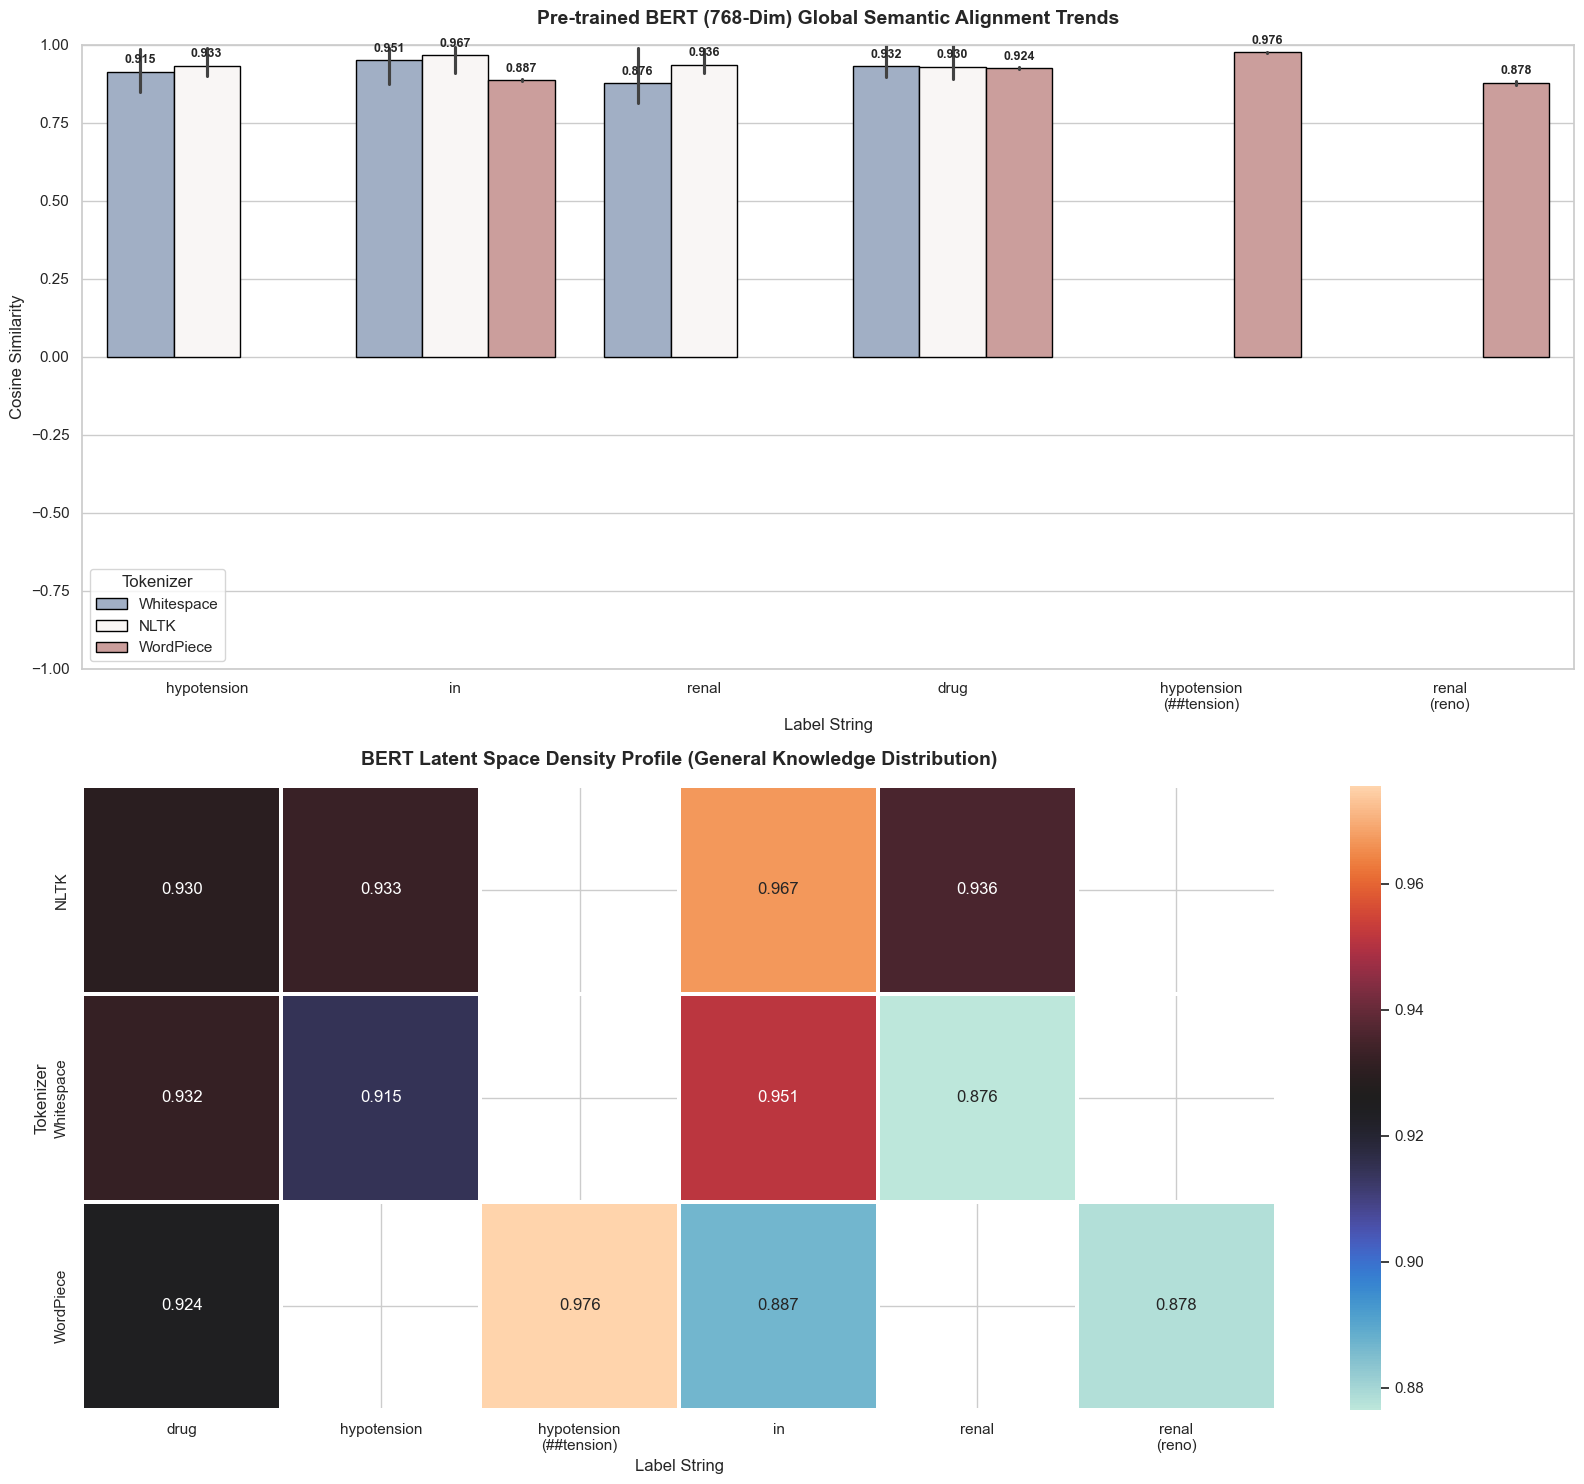

In [42]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from gensim.models import KeyedVectors

# 1. Configuration
model_base_dir = "./trained_embeddings/bert"
bert_models = {
    "Whitespace": "bert_withwhitespace_768.model",
    "NLTK": "bert_withnltk_768.model",
    "WordPiece": "bert_withwordpiece_768.model"
}

validation_queries = {
    "Disease Entity": "hypotension",
    "Stopword/Preposition": "in",
    "Anatomical Term": "renal",
    "General Medical": "drug"
}

bert_eval_data = []

print("Loading Pre-trained BERT artifacts (768-Dim) for evaluation...")
print("====================================================================")

for tokenizer_name, filename in bert_models.items():
    model_path = os.path.join(model_base_dir, filename)
    
    if not os.path.exists(model_path):
        print(f"[Error] Model missing at destination: {model_path}")
        continue
        
    model = KeyedVectors.load(model_path)
    print(f"Loaded {filename} successfully. Vocab Size: {len(model.index_to_key):,}")
    
    for category, query_token in validation_queries.items():
        # Handle WordPiece fallbacks just like we did in ELMo
        target_token = query_token
        if tokenizer_name == "WordPiece" and query_token == "hypotension":
            target_token = "##tension"
        elif tokenizer_name == "WordPiece" and query_token == "renal":
            target_token = "reno"
            
        if target_token in model.key_to_index:
            try:
                similar_tokens = model.most_similar(target_token, topn=3)
                for rank, (token, similarity) in enumerate(similar_tokens, 1):
                    bert_eval_data.append({
                        "Tokenizer": tokenizer_name,
                        "Category": category,
                        "Target Word": query_token,
                        "Label String": f"{query_token}\n({target_token})" if target_token != query_token else query_token,
                        "Discovered Token": token,
                        "Cosine Similarity": similarity,
                        "Rank": f"Rank {rank}"
                    })
            except Exception as e:
                print(f"  -> Error mining '{target_token}' in {tokenizer_name}: {str(e)}")

df_bert = pd.DataFrame(bert_eval_data)
print("====================================================================")
print("Generating detailed analytical plots for BERT...")

# 2. Plotting
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 1, figsize=(16, 15))

# Plot 1: Grouped Bar Chart
sns.barplot(
    data=df_bert,
    x="Label String",
    y="Cosine Similarity",
    hue="Tokenizer",
    palette="vlag",
    edgecolor="black",
    ax=axes[0]
)
axes[0].set_title("Pre-trained BERT (768-Dim) Global Semantic Alignment Trends", fontsize=14, fontweight="bold", pad=15)
axes[0].set_ylim(-1.0, 1.0)
for container in axes[0].containers:
    axes[0].bar_label(container, fmt="%.3f", padding=4, fontsize=9, fontweight="bold")

# Plot 2: Heatmap
pivot_df = df_bert.pivot_table(values="Cosine Similarity", index="Tokenizer", columns="Label String", aggfunc="mean")
sns.heatmap(pivot_df, annot=True, fmt=".3f", cmap="icefire", linewidths=1.5, ax=axes[1])
axes[1].set_title("BERT Latent Space Density Profile (General Knowledge Distribution)", fontsize=14, fontweight="bold", pad=15)

plt.tight_layout()
plt.show()
print("====================================================================")

## Step 05: Sequence Modeling

### Model A — Static Bi-LSTM Architecture (Input Dim = 300)

In [1]:
import torch
import torch.nn as nn

class StaticBiLSTM_NER(nn.Module):
    def __init__(self, hidden_dim, tagset_size, dropout_rate=0.5):
        super(StaticBiLSTM_NER, self).__init__()
        
        # Static Embeddings (Word2Vec, FastText, GloVe) = 300 Dimensions
        self.input_dim = 300
        
        # Spatial 1D Dropout to regularize word embedding dimensions uniformly
        self.embedding_dropout = nn.Dropout1d(p=dropout_rate)
        
        # 1. Residual Projection: Aligns 300-Dim input to match LSTM's hidden_dim output
        # Necessary to safely compute skip-connections [Input + LSTM_Out]
        self.residual_projector = nn.Linear(self.input_dim, hidden_dim)
        
        # Core Sequence Encoder: Stacked Bidirectional LSTM layers
        self.lstm = nn.LSTM(
            input_size=self.input_dim, 
            hidden_size=hidden_dim // 2, 
            num_layers=2, 
            bidirectional=True, 
            batch_first=True,
            dropout=dropout_rate if dropout_rate > 0 else 0
        )
        
        # Layer Normalization to stabilize internal state trajectories
        self.layer_norm = nn.LayerNorm(hidden_dim)
        
        # 2. Intermediate Feature Dense Layer for complex semantic capturing
        self.intermediate_dense = nn.Linear(hidden_dim, hidden_dim // 2)
        
        # Modern Non-linear Activation Function for smoother gradient flows
        self.activation = nn.Mish()
        self.output_dropout = nn.Dropout(p=dropout_rate)
        
        # Final Inference Head: Mapping enhanced patterns to target NER tags
        self.hidden2tag = nn.Linear(hidden_dim // 2, tagset_size)
        
        # 3. Apply Xavier Uniform weight initialization for accelerated convergence
        self._init_weights()
        
    def _init_weights(self):
        """
        Applies mathematical initialization bounds to prevent vanishing/exploding gradients.
        """
        for name, param in self.named_parameters():
            if 'weight' in name and len(param.shape) >= 2:
                nn.init.xavier_uniform_(param)
            elif 'bias' in name:
                nn.init.constant_(param, 0.0)
                
    def forward(self, x):
        # Input tensor shape: [Batch_Size, Max_Seq_Len, 300]
        
        # Generate baseline residual trace directly from input mapping
        residual_trace = self.residual_projector(x) # [Batch_Size, Max_Seq_Len, Hidden_Dim]
        
        # Apply Spatial Dropout channel-wise
        x = x.permute(0, 2, 1)
        x = self.embedding_dropout(x)
        x = x.permute(0, 2, 1)
        
        # Extract sequence dependency states via Bi-LSTM
        lstm_out, _ = self.lstm(x) # [Batch_Size, Max_Seq_Len, Hidden_Dim]
        
        # 💡 Optimization: Compute Residual Skip Connection to bypass information loss
        # Combines raw semantic features with hidden sequential trace
        lstm_out = lstm_out + residual_trace
        
        # Standardize representation boundaries
        lstm_out = self.layer_norm(lstm_out)
        
        # Route features through intermediate dense transformation blocks
        dense_features = self.intermediate_dense(lstm_out)
        dense_features = self.activation(dense_features)
        dense_features = self.output_dropout(dense_features)
        
        # Generate definitive tag allocation logits matrix
        logits = self.hidden2tag(dense_features) 
        return logits

print("Successfully compiled Optimized Model A: High-Performance Static Bi-LSTM Architecture.")

Successfully compiled Optimized Model A: High-Performance Static Bi-LSTM Architecture.


### Model B — Contextual Bi-LSTM Architecture (Input Dim = 768)

In [2]:
import torch
import torch.nn as nn

class ContextualBiLSTM_NER(nn.Module):
    def __init__(self, hidden_dim, tagset_size, dropout_rate=0.5):
        super(ContextualBiLSTM_NER, self).__init__()
        
        # Contextual Embeddings (ELMo, BERT) = 768 Dimensions
        self.input_dim = 768
        
        # Spatial 1D Dropout optimized for high-dimensional sequence density
        self.embedding_dropout = nn.Dropout1d(p=dropout_rate)
        
        # 1. Contextual Residual Projector: Maps 768-Dim input to hidden_dim 
        # to allow seamless skip-connections [Projected_Input + LSTM_Out]
        self.residual_projector = nn.Linear(self.input_dim, hidden_dim)
        
        # Deep Contextual Encoder: Heavy 2-layered Bidirectional LSTM Stack
        self.lstm = nn.LSTM(
            input_size=self.input_dim, 
            hidden_size=hidden_dim // 2, 
            num_layers=2, 
            bidirectional=True, 
            batch_first=True,
            dropout=dropout_rate if dropout_rate > 0 else 0
        )
        
        # Layer Normalization calibrated for dense transformer-derived distributions
        self.layer_norm = nn.LayerNorm(hidden_dim)
        
        # 2. Intermediate Feature Dense Layer for advanced non-linear transformation
        self.intermediate_dense = nn.Linear(hidden_dim, hidden_dim // 2)
        
        # Modern Mish activation function for smoother gradient backpropagation
        self.activation = nn.Mish()
        self.output_dropout = nn.Dropout(p=dropout_rate)
        
        # Final Inference Head: Maps high-density features into definitive target NER tags
        self.hidden2tag = nn.Linear(hidden_dim // 2, tagset_size)
        
        # 3. Apply Xavier Uniform weight initialization for accelerated convergence
        self._init_weights()
        
    def _init_weights(self):
        """
        Applies mathematical initialization boundaries to avoid exploding or vanishing gradients.
        """
        for name, param in self.named_parameters():
            if 'weight' in name and len(param.shape) >= 2:
                nn.init.xavier_uniform_(param)
            elif 'bias' in name:
                nn.init.constant_(param, 0.0)
                
    def forward(self, x):
        # Input tensor shape: [Batch_Size, Max_Seq_Len, 768]
        
        # Generate baseline residual trace by projecting 768-Dim input to hidden_dim
        residual_trace = self.residual_projector(x) # [Batch_Size, Max_Seq_Len, Hidden_Dim]
        
        # Apply spatial dropout channel-wise across contextual blocks
        x = x.permute(0, 2, 1)
        x = self.embedding_dropout(x)
        x = x.permute(0, 2, 1)
        
        # Execute forward and backward sequences through dense LSTM layers
        lstm_out, _ = self.lstm(x) # [Batch_Size, Max_Seq_Len, Hidden_Dim]
        
        # 💡 Optimization: Compute Residual Skip Connection
        # Injecting raw contextual representations directly into sequential trace
        lstm_out = lstm_out + residual_trace
        
        # Normalize hidden states matrix boundaries
        lstm_out = self.layer_norm(lstm_out)
        
        # Route deep features through intermediate dense transformation layers
        dense_features = self.intermediate_dense(lstm_out)
        dense_features = self.activation(dense_features)
        dense_features = self.output_dropout(dense_features)
        
        # Compute final classification logits matrix
        logits = self.hidden2tag(dense_features) 
        return logits

print("Successfully compiled Optimized Model B: High-Performance Contextual Bi-LSTM Architecture.")

Successfully compiled Optimized Model B: High-Performance Contextual Bi-LSTM Architecture.


## Step 06: Training for Token classification  